<a href="https://colab.research.google.com/github/ilyilayda/multi-agent-pneumonia-xai/blob/main/multi_agent_pneumonia_xai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

In [ ]:
# ============================================================
# REPRODUCIBILITY AND RUN CONFIGURATION
# ============================================================

import json
import hashlib
import platform
from datetime import datetime

SEED = 42

# Python
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print("RUN ID:", RUN_ID)
print("Random seed:", SEED)

RUN ID: 20260827_103144
Random seed: 42


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla T4


In [ ]:
# ============================================================
# KAGGLE CREDENTIALS FROM COLAB SECRETS
# ============================================================

from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get(
    "KAGGLE_USERNAME"
)

os.environ["KAGGLE_KEY"] = userdata.get(
    "KAGGLE_KEY"
)

print(
    "Kaggle credentials loaded from Colab Secrets."
)

Kaggle credentials loaded from Colab Secrets.


In [ ]:
!pip install -q kaggle

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:22<00:00, 111MB/s]



In [ ]:
!unzip -oq chest-xray-pneumonia.zip -d /content/

In [ ]:
import os
import shutil
import random

In [ ]:
base_dir = "/content/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Train klasörü:", os.listdir(train_dir))
print("Validation klasörü:", os.listdir(val_dir))
print("Test klasörü:", os.listdir(test_dir))

Train klasörü: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Validation klasörü: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Test klasörü: ['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [ ]:
#Görselleri modele uygun hale getirme

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.03, 0.03)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
# ============================================================
# DUPLICATE-SAFE DATASET CREATION
# AND INTERNAL TRAIN / VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import pandas as pd
import hashlib

# ------------------------------------------------------------
# Helper: exact file hash
# ------------------------------------------------------------

def compute_file_md5(filepath):
    md5 = hashlib.md5()

    with open(filepath, "rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b""
        ):
            md5.update(block)

    return md5.hexdigest()


# ------------------------------------------------------------
# Base training dataset
# Used only for file paths and labels
# ------------------------------------------------------------

base_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=None
)

train_targets = np.array(
    base_train_dataset.targets
)

all_indices = np.arange(
    len(base_train_dataset)
)

# ------------------------------------------------------------
# Build file-level metadata + exact hashes
# ------------------------------------------------------------

split_base_df = pd.DataFrame({
    "original_index": all_indices,
    "filepath": [
        path
        for path, label
        in base_train_dataset.samples
    ],
    "label": train_targets
})

split_base_df["md5"] = (
    split_base_df["filepath"]
    .apply(compute_file_md5)
)

# ------------------------------------------------------------
# Safety check:
# the same exact image should not have conflicting labels
# ------------------------------------------------------------

hash_label_counts = (
    split_base_df
    .groupby("md5")["label"]
    .nunique()
)

conflicting_hashes = (
    hash_label_counts[
        hash_label_counts > 1
    ]
)

print(
    "Hashes with conflicting labels:",
    len(conflicting_hashes)
)

assert len(conflicting_hashes) == 0, (
    "Exact duplicate images with conflicting labels were found."
)

# ------------------------------------------------------------
# Create one row per UNIQUE image hash
# Duplicates will therefore stay in the same split
# ------------------------------------------------------------

unique_hash_df = (
    split_base_df
    .groupby("md5", as_index=False)
    .agg(
        label=("label", "first"),
        number_of_files=("filepath", "count")
    )
)

# ------------------------------------------------------------
# Stratified 80/20 split AT HASH-GROUP LEVEL
# ------------------------------------------------------------

train_hashes, val_hashes = train_test_split(
    unique_hash_df["md5"].values,
    test_size=0.20,
    random_state=SEED,
    stratify=unique_hash_df["label"].values
)

train_hash_set = set(train_hashes)
val_hash_set = set(val_hashes)

# ------------------------------------------------------------
# Convert hash groups back to original image indices
# ------------------------------------------------------------

internal_train_idx = (
    split_base_df.loc[
        split_base_df["md5"].isin(
            train_hash_set
        ),
        "original_index"
    ]
    .to_numpy()
)

internal_val_idx = (
    split_base_df.loc[
        split_base_df["md5"].isin(
            val_hash_set
        ),
        "original_index"
    ]
    .to_numpy()
)

# ------------------------------------------------------------
# Confirm there is NO exact duplicate leakage
# ------------------------------------------------------------

internal_train_hashes = set(
    split_base_df.loc[
        split_base_df[
            "original_index"
        ].isin(internal_train_idx),
        "md5"
    ]
)

internal_val_hashes = set(
    split_base_df.loc[
        split_base_df[
            "original_index"
        ].isin(internal_val_idx),
        "md5"
    ]
)

internal_duplicate_overlap = (
    internal_train_hashes
    &
    internal_val_hashes
)

print(
    "Duplicate hashes between "
    "internal train and validation:",
    len(internal_duplicate_overlap)
)

assert len(internal_duplicate_overlap) == 0, (
    "Duplicate leakage remains between "
    "internal train and validation."
)

# ------------------------------------------------------------
# Separate dataset objects:
# training uses augmentation;
# validation uses deterministic transform
# ------------------------------------------------------------

train_dataset_full = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

internal_val_dataset_full = datasets.ImageFolder(
    root=train_dir,
    transform=test_transform
)

internal_train_dataset = Subset(
    train_dataset_full,
    internal_train_idx
)

internal_val_dataset = Subset(
    internal_val_dataset_full,
    internal_val_idx
)

# ------------------------------------------------------------
# Original Kaggle validation folder
# retained only for dataset documentation
# ------------------------------------------------------------

original_val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transform
)

# ------------------------------------------------------------
# Official test dataset
# ------------------------------------------------------------

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

batch_size = 16

generator = torch.Generator()
generator.manual_seed(SEED)

internal_train_loader = DataLoader(
    internal_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=generator,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

internal_val_loader = DataLoader(
    internal_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

original_val_loader = DataLoader(
    original_val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

# ------------------------------------------------------------
# Split summary
# ------------------------------------------------------------

split_summary = pd.DataFrame({
    "Split": [
        "Internal training",
        "Internal validation",
        "Original Kaggle validation",
        "Official test"
    ],
    "Number of images": [
        len(internal_train_dataset),
        len(internal_val_dataset),
        len(original_val_dataset),
        len(test_dataset)
    ]
})

display(split_summary)

print(
    "Classes:",
    base_train_dataset.classes
)

Hashes with conflicting labels: 0
Duplicate hashes between internal train and validation: 0


,Split,Number of images
0,Internal training,4174
1,Internal validation,1042
2,Original Kaggle validation,16
3,Official test,624


Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
# ============================================================
# SAVE DUPLICATE-SAFE INTERNAL SPLIT MANIFEST
# ============================================================

internal_train_idx_set = set(
    internal_train_idx
)

split_manifest = (
    split_base_df.copy()
)

split_manifest["split"] = [
    (
        "internal_train"
        if idx
        in internal_train_idx_set
        else
        "internal_validation"
    )
    for idx in split_manifest[
        "original_index"
    ]
]

split_manifest_path = (
    f"split_manifest_{RUN_ID}.csv"
)

split_manifest.to_csv(
    split_manifest_path,
    index=False
)

print(
    "Saved:",
    split_manifest_path
)

display(
    split_manifest.head()
)

Saved: split_manifest_20260827_103144.csv


,original_index,filepath,label,md5,split
0,0,/content/chest_xray/chest_xray/train/NORMAL/IM...,0,20e1b8286b2d4e7a9869d42abd1cbf91,internal_validation
1,1,/content/chest_xray/chest_xray/train/NORMAL/IM...,0,9299d3c610ad02c31c30469c9a4c2431,internal_validation
2,2,/content/chest_xray/chest_xray/train/NORMAL/IM...,0,4b873c9f031149dccd93d51e092215ca,internal_validation
3,3,/content/chest_xray/chest_xray/train/NORMAL/IM...,0,f510c0d0ff70e725449ecbdf93553a70,internal_train
4,4,/content/chest_xray/chest_xray/train/NORMAL/IM...,0,3c0c7a39407e411aa83b854f8f8fa8f0,internal_train


In [ ]:
# ============================================================
# CROSS-FOLDER EXACT DUPLICATE CHECK
# ============================================================

def build_hash_table(
    dataset,
    split_name
):
    records = []

    for filepath, label in dataset.samples:

        records.append({
            "filepath":
                filepath,

            "label":
                label,

            "split":
                split_name,

            "md5":
                compute_file_md5(
                    filepath
                )
        })

    return pd.DataFrame(
        records
    )


train_hash_df = build_hash_table(
    base_train_dataset,
    "original_train"
)

val_hash_df = build_hash_table(
    datasets.ImageFolder(
        root=val_dir,
        transform=None
    ),
    "original_validation"
)

test_hash_df = build_hash_table(
    datasets.ImageFolder(
        root=test_dir,
        transform=None
    ),
    "official_test"
)

train_hash_set_full = set(
    train_hash_df["md5"]
)

original_val_hash_set = set(
    val_hash_df["md5"]
)

official_test_hash_set = set(
    test_hash_df["md5"]
)

train_test_overlap = (
    train_hash_set_full
    &
    official_test_hash_set
)

train_original_val_overlap = (
    train_hash_set_full
    &
    original_val_hash_set
)

original_val_test_overlap = (
    original_val_hash_set
    &
    official_test_hash_set
)

print(
    "Original train ↔ official test duplicate hashes:",
    len(train_test_overlap)
)

print(
    "Original train ↔ original validation duplicate hashes:",
    len(train_original_val_overlap)
)

print(
    "Original validation ↔ official test duplicate hashes:",
    len(original_val_test_overlap)
)

Original train ↔ official test duplicate hashes: 0
Original train ↔ original validation duplicate hashes: 0
Original validation ↔ official test duplicate hashes: 0


In [ ]:
# Full original training folder
train_hash_df = build_hash_table(
    base_train_dataset,
    "original_train_folder"
)

val_hash_df = build_hash_table(
    original_val_dataset,
    "original_validation_folder"
)

test_hash_df = build_hash_table(
    test_dataset,
    "official_test"
)

all_hash_df = pd.concat(
    [
        train_hash_df,
        val_hash_df,
        test_hash_df
    ],
    ignore_index=True
)

duplicate_groups = (
    all_hash_df[
        all_hash_df.duplicated(
            subset=["md5"],
            keep=False
        )
    ]
    .sort_values("md5")
)

print(
    "Number of files involved in duplicate groups:",
    len(duplicate_groups)
)

display(
    duplicate_groups.head(20)
)

Number of files involved in duplicate groups: 62


,filepath,label,split,md5
5371,/content/chest_xray/chest_xray/test/NORMAL/NOR...,0,official_test,05c43c853e8209bf0423f73a6f0a8c58
5370,/content/chest_xray/chest_xray/test/NORMAL/NOR...,0,official_test,05c43c853e8209bf0423f73a6f0a8c58
2674,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,061c1fac2e79c2d435a6d4c1e35894e7
2673,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,061c1fac2e79c2d435a6d4c1e35894e7
2068,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,077fce04eafc798401239d127a84f5f0
2069,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,077fce04eafc798401239d127a84f5f0
2372,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,23cd1cdafc40ad7f67e6d076ffec52ab
2371,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,23cd1cdafc40ad7f67e6d076ffec52ab
3494,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,23d698733d4709babc2bf0b40ea67cf4
3495,/content/chest_xray/chest_xray/train/PNEUMONIA...,1,original_train_folder,23d698733d4709babc2bf0b40ea67cf4


In [ ]:
# ============================================================
# FINAL INTERNAL SPLIT DUPLICATE CHECK
# ============================================================

train_internal_hashes = set(
    split_manifest.loc[
        split_manifest["split"]
        == "internal_train",
        "md5"
    ]
)

val_internal_hashes = set(
    split_manifest.loc[
        split_manifest["split"]
        == "internal_validation",
        "md5"
    ]
)

internal_overlap = (
    train_internal_hashes
    &
    val_internal_hashes
)

print(
    "Duplicate hashes between "
    "internal train and internal validation:",
    len(internal_overlap)
)

assert len(internal_overlap) == 0

Duplicate hashes between internal train and internal validation: 0


In [ ]:
# ============================================================
# CLASS WEIGHTS FROM INTERNAL TRAINING SPLIT ONLY
# ============================================================

from collections import Counter

internal_train_labels = train_targets[internal_train_idx]

class_counts = Counter(internal_train_labels)

print("Internal training class counts:", class_counts)
print("Class names:", base_train_dataset.classes)

num_samples = len(internal_train_labels)
num_classes = len(base_train_dataset.classes)

class_weights_list = []

for class_idx in range(num_classes):

    n_class = class_counts[class_idx]

    weight = (
        num_samples /
        (num_classes * n_class)
    )

    class_weights_list.append(weight)

class_weights = torch.tensor(
    class_weights_list,
    dtype=torch.float32,
    device=device
)

print("Class weights:", class_weights)

Internal training class counts: Counter({np.int64(1): 3101, np.int64(0): 1073})
Class names: ['NORMAL', 'PNEUMONIA']
Class weights: tensor([1.9450, 0.6730], device='cuda:0')


In [ ]:
#Birkaç örnek görüntü göster

    # ============================================================
# DISPLAY SAMPLE TRAINING IMAGES
# ============================================================

def show_samples(dataset, num_images=6):

    plt.figure(figsize=(15, 8))

    # Dataset'teki sınıf isimlerini al
    class_names = dataset.classes

    for i in range(min(num_images, len(dataset))):

        image, label = dataset[i]

        # Tensor -> numpy
        image = image.cpu().numpy()

        # (C, H, W) -> (H, W, C)
        image = np.transpose(
            image,
            (1, 2, 0)
        )

        # Normalize işlemini geri al
        image = (image * 0.5) + 0.5

        # Güvenli görüntüleme aralığı
        image = np.clip(
            image,
            0,
            1
        )

        plt.subplot(
            2,
            3,
            i + 1
        )

        plt.imshow(image)

        plt.title(
            class_names[label]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

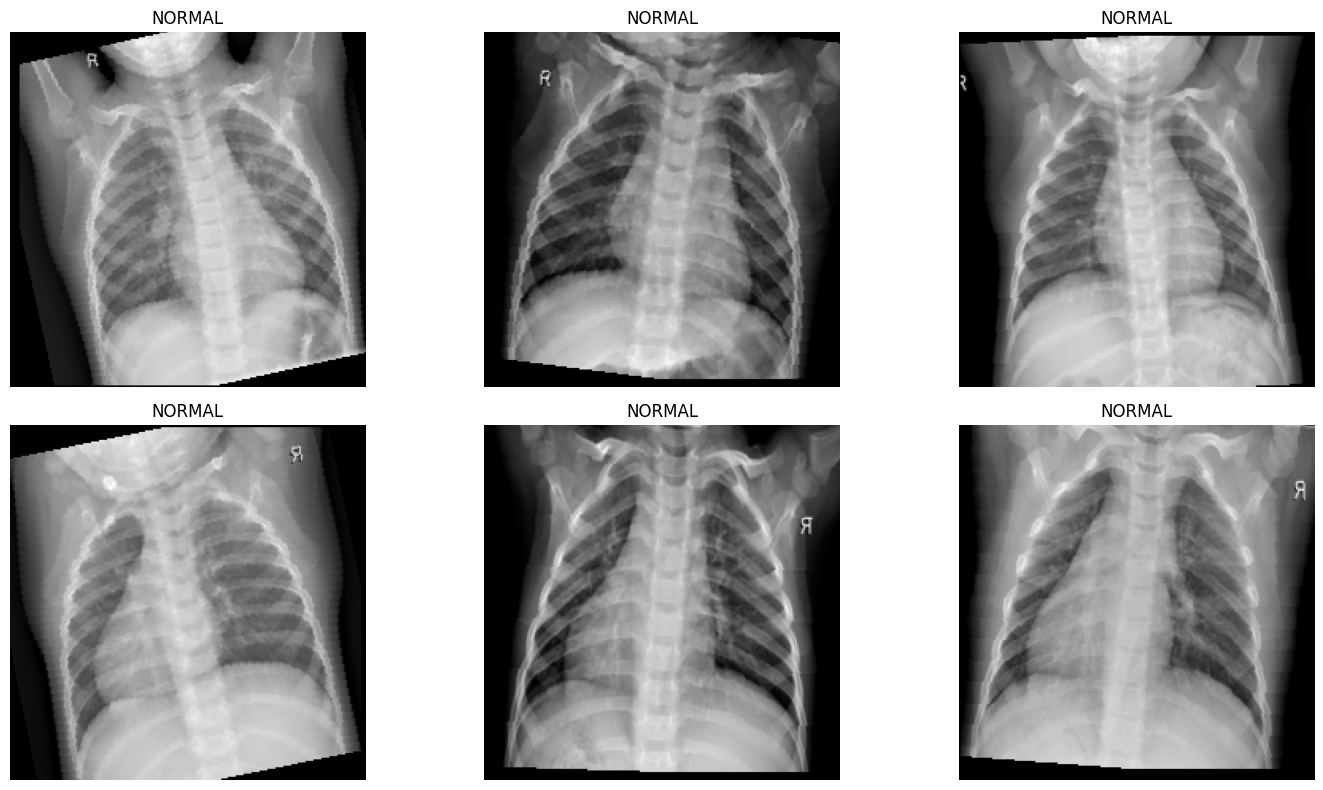

In [ ]:
show_samples(train_dataset_full, num_images=6)

# İlk basit CNN modeli

In [ ]:
#Güncellenmiş model
class SimpleCNNImproved(nn.Module):
    def __init__(self):
        super(SimpleCNNImproved, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
sample_image, sample_label = train_dataset_full[0]
print("Görüntü boyutu:", sample_image.shape)

Görüntü boyutu: torch.Size([3, 224, 224])


In [ ]:
#Model, weighted loss ve optimizer
model = SimpleCNNImproved().to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

print(model)

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
# ============================================================
# SINGLE-BATCH FORWARD PASS TEST
# ============================================================
# Modelin internal training setinden bir batch'i
# sorunsuz işleyip işleyemediğini kontrol ediyoruz.

images, labels = next(iter(internal_train_loader))

images = images.to(device)
labels = labels.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape : torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 2])
Labels shape: torch.Size([16])


In [ ]:
#Accuracy hesaplama fonksiyonu
def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1) #en yüksek skorlu sınıfı seçer.
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    acc = correct / total
    return acc

In [ ]:
#Training fonksiyonu
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        _, preds = torch.max(
            outputs,
            1
        )

        batch_size_current = labels.size(0)

        running_loss += (
            loss.item() *
            batch_size_current
        )

        correct += (
            preds == labels
        ).sum().item()

        total += batch_size_current

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
#Validation fonksiyonu
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            _, preds = torch.max(
                outputs,
                1
            )

            batch_size_current = labels.size(0)

            running_loss += (
                loss.item() *
                batch_size_current
            )

            correct += (
                preds == labels
            ).sum().item()

            total += batch_size_current

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [ ]:
# ============================================================
# TRAIN IMPROVED CNN
# MODEL SELECTION USES INTERNAL VALIDATION ONLY
# ============================================================

best_val_acc = -1.0
num_epochs = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_cnn_checkpoint = (
    f"best_improved_cnn_{RUN_ID}.pth"
)

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=internal_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = validate_one_epoch(
        model=model,
        loader=internal_val_loader,
        criterion=criterion,
        device=device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "run_id": RUN_ID,
                "seed": SEED,
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "internal_validation_accuracy":
                    val_acc
            },
            best_cnn_checkpoint
        )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss={train_loss:.4f} | "
        f"Train Acc={train_acc:.4f} | "
        f"Internal Val Loss={val_loss:.4f} | "
        f"Internal Val Acc={val_acc:.4f}"
    )

print(
    "\nBest internal-validation accuracy:",
    f"{best_val_acc:.4f}"
)

print(
    "Checkpoint:",
    best_cnn_checkpoint
)

Epoch [1/10] | Train Loss=0.4496 | Train Acc=0.7731 | Internal Val Loss=0.4381 | Internal Val Acc=0.8052
Epoch [2/10] | Train Loss=0.2917 | Train Acc=0.8831 | Internal Val Loss=0.2205 | Internal Val Acc=0.9338
Epoch [3/10] | Train Loss=0.2366 | Train Acc=0.9116 | Internal Val Loss=0.1574 | Internal Val Acc=0.9491
Epoch [4/10] | Train Loss=0.2109 | Train Acc=0.9248 | Internal Val Loss=0.2297 | Internal Val Acc=0.9040
Epoch [5/10] | Train Loss=0.2000 | Train Acc=0.9264 | Internal Val Loss=0.2540 | Internal Val Acc=0.8916
Epoch [6/10] | Train Loss=0.1882 | Train Acc=0.9329 | Internal Val Loss=0.2702 | Internal Val Acc=0.8877
Epoch [7/10] | Train Loss=0.1656 | Train Acc=0.9415 | Internal Val Loss=0.1356 | Internal Val Acc=0.9530
Epoch [8/10] | Train Loss=0.1621 | Train Acc=0.9413 | Internal Val Loss=0.1428 | Internal Val Acc=0.9511
Epoch [9/10] | Train Loss=0.1649 | Train Acc=0.9425 | Internal Val Loss=0.1137 | Internal Val Acc=0.9616
Epoch [10/10] | Train Loss=0.1474 | Train Acc=0.9449 | 

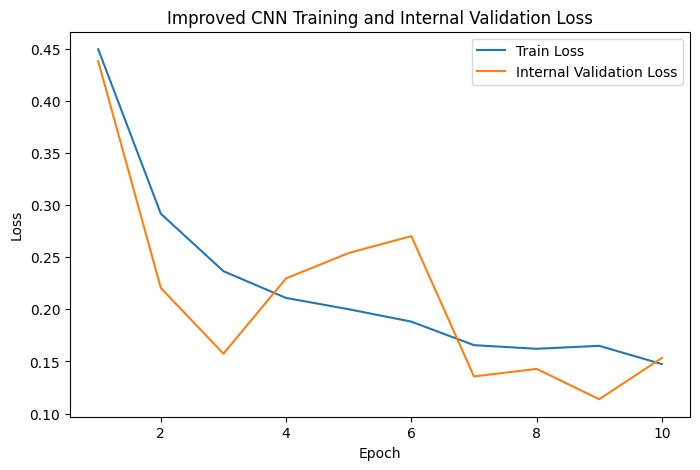

In [ ]:
#Loss grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), val_losses, label="Internal Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved CNN Training and Internal Validation Loss")
plt.legend()
plt.show()

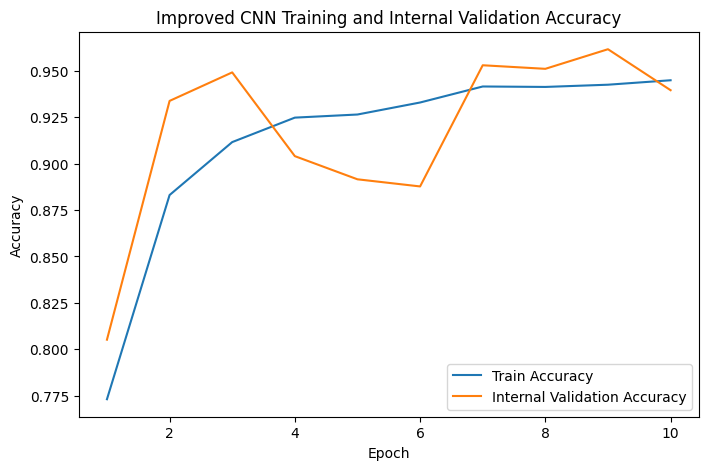

In [ ]:
#Accuracy grafiği çizme
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, label="Internal Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved CNN Training and Internal Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
    brier_score_loss
)

import pandas as pd
import seaborn as sns

In [ ]:
# ============================================================
# LOAD BEST IMPROVED CNN CHECKPOINT
# ============================================================

best_model = SimpleCNNImproved().to(device)

cnn_checkpoint = torch.load(
    best_cnn_checkpoint,
    map_location=device
)

best_model.load_state_dict(
    cnn_checkpoint["model_state_dict"]
)

best_model.eval()

print("Improved CNN loaded.")
print("Run ID:", cnn_checkpoint["run_id"])
print("Seed:", cnn_checkpoint["seed"])
print("Selected epoch:", cnn_checkpoint["epoch"])
print(
    "Internal validation accuracy:",
    cnn_checkpoint[
        "internal_validation_accuracy"
    ]
)

Improved CNN loaded.
Run ID: 20260827_103144
Seed: 42
Selected epoch: 9
Internal validation accuracy: 0.9616122840690979


In [ ]:
# ============================================================
# CREATE LEGACY CHECKPOINT FILE FOR OLD CELLS
# ============================================================

torch.save(
    cnn_checkpoint["model_state_dict"],
    "best_simple_cnn_weighted.pth"
)

print("Legacy checkpoint created: best_simple_cnn_weighted.pth")

Legacy checkpoint created: best_simple_cnn_weighted.pth


In [ ]:
# ============================================================
# GENERAL CLASSIFICATION EVALUATION FUNCTION
# ============================================================

def evaluate_classifier(
    model,
    loader,
    device
):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            y_true.extend(
                labels.cpu().numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

            # Probability of PNEUMONIA class
            y_prob.extend(
                probabilities[:, 1]
                .cpu()
                .numpy()
            )

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    ppv = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else np.nan
    )

    metrics = {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "sensitivity":
            sensitivity,

        "specificity":
            specificity,

        "precision_ppv":
            ppv,

        "npv":
            npv,

        "f1":
            f1_score(
                y_true,
                y_pred
            ),

        "roc_auc":
            roc_auc_score(
                y_true,
                y_prob
            ),

        "brier_score":
            brier_score_loss(
                y_true,
                y_prob
            ),

        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

    return (
        metrics,
        y_true,
        y_pred,
        y_prob,
        cm
    )

# ResNet-18 Transfer Learning Baseline

In [ ]:
import torchvision.models as models
from torchvision.models import ResNet18_Weights

In [ ]:
#ResNet-18 modelini oluştur
resnet18 = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Son fully connected katmanı değiştiriyoruz
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 2)

resnet18 = resnet18.to(device)

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 145MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
#Loss ve optimizer tanımla
criterion_resnet = nn.CrossEntropyLoss(weight=class_weights)
optimizer_resnet = optim.Adam(resnet18.parameters(), lr=1e-4)

In [ ]:
# ============================================================
# TRAIN RESNET-18
# MODEL SELECTION USES INTERNAL VALIDATION ONLY
# ============================================================

best_val_acc_resnet = -1.0
num_epochs = 10

resnet_train_losses = []
resnet_train_accuracies = []

resnet_val_losses = []
resnet_val_accuracies = []

best_resnet_checkpoint = (
    f"best_resnet18_{RUN_ID}.pth"
)

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model=resnet18,
        loader=internal_train_loader,
        criterion=criterion_resnet,
        optimizer=optimizer_resnet,
        device=device
    )

    val_loss, val_acc = validate_one_epoch(
        model=resnet18,
        loader=internal_val_loader,
        criterion=criterion_resnet,
        device=device
    )

    resnet_train_losses.append(
        train_loss
    )

    resnet_train_accuracies.append(
        train_acc
    )

    resnet_val_losses.append(
        val_loss
    )

    resnet_val_accuracies.append(
        val_acc
    )

    if val_acc > best_val_acc_resnet:

        best_val_acc_resnet = val_acc

        torch.save(
            {
                "run_id": RUN_ID,
                "seed": SEED,
                "epoch": epoch + 1,

                "model_state_dict":
                    resnet18.state_dict(),

                "optimizer_state_dict":
                    optimizer_resnet.state_dict(),

                "internal_validation_accuracy":
                    val_acc,

                "pretrained_weights":
                    "ResNet18_Weights.DEFAULT"
            },
            best_resnet_checkpoint
        )

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] | "
        f"Train Loss={train_loss:.4f} | "
        f"Train Acc={train_acc:.4f} | "
        f"Internal Val Loss={val_loss:.4f} | "
        f"Internal Val Acc={val_acc:.4f}"
    )

print(
    "\nBest ResNet-18 internal-validation accuracy:",
    f"{best_val_acc_resnet:.4f}"
)

Epoch [1/10] | Train Loss=0.1769 | Train Acc=0.9226 | Internal Val Loss=0.0556 | Internal Val Acc=0.9818
Epoch [2/10] | Train Loss=0.1080 | Train Acc=0.9609 | Internal Val Loss=0.0523 | Internal Val Acc=0.9856
Epoch [3/10] | Train Loss=0.0805 | Train Acc=0.9708 | Internal Val Loss=0.0744 | Internal Val Acc=0.9722
Epoch [4/10] | Train Loss=0.0663 | Train Acc=0.9772 | Internal Val Loss=0.0438 | Internal Val Acc=0.9866
Epoch [5/10] | Train Loss=0.0592 | Train Acc=0.9806 | Internal Val Loss=0.0490 | Internal Val Acc=0.9818
Epoch [6/10] | Train Loss=0.0466 | Train Acc=0.9820 | Internal Val Loss=0.0425 | Internal Val Acc=0.9904
Epoch [7/10] | Train Loss=0.0484 | Train Acc=0.9830 | Internal Val Loss=0.0294 | Internal Val Acc=0.9914
Epoch [8/10] | Train Loss=0.0399 | Train Acc=0.9842 | Internal Val Loss=0.0578 | Internal Val Acc=0.9693
Epoch [9/10] | Train Loss=0.0340 | Train Acc=0.9878 | Internal Val Loss=0.0480 | Internal Val Acc=0.9866
Epoch [10/10] | Train Loss=0.0448 | Train Acc=0.9861 | 

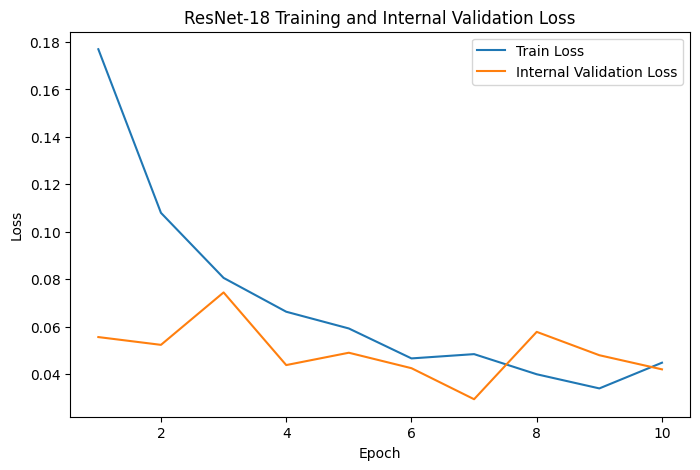

In [ ]:
#ResNet-18 loss grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_losses, label="Train Loss")
plt.plot(range(1, num_epochs + 1), resnet_val_losses, label="Internal Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-18 Training and Internal Validation Loss")
plt.legend()
plt.show()

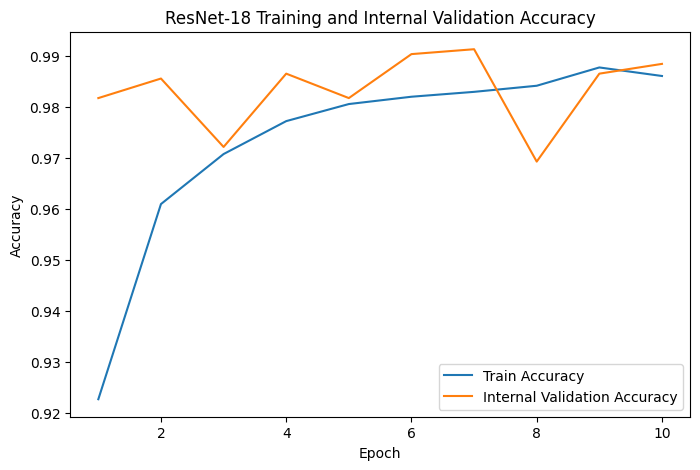

In [ ]:
#ResNet-18 accuracy grafiği
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), resnet_train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs + 1), resnet_val_accuracies, label="Internal Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet-18 Training and Internal Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# LOAD BEST RESNET-18 CHECKPOINT
# ============================================================

best_resnet18 = models.resnet18(
    weights=None
)

num_features = (
    best_resnet18.fc.in_features
)

best_resnet18.fc = nn.Linear(
    num_features,
    2
)

resnet_checkpoint = torch.load(
    best_resnet_checkpoint,
    map_location=device
)

best_resnet18.load_state_dict(
    resnet_checkpoint[
        "model_state_dict"
    ]
)

best_resnet18 = (
    best_resnet18.to(device)
)

best_resnet18.eval()

print("Best ResNet-18 loaded.")
print("Run ID:", resnet_checkpoint["run_id"])
print("Seed:", resnet_checkpoint["seed"])
print("Selected epoch:", resnet_checkpoint["epoch"])

print(
    "Internal validation accuracy:",
    resnet_checkpoint[
        "internal_validation_accuracy"
    ]
)

Best ResNet-18 loaded.
Run ID: 20260827_103144
Seed: 42
Selected epoch: 7
Internal validation accuracy: 0.991362763915547


# Locked Final Test Evaluation

The official 624-image test set is used only after model training and checkpoint selection are complete.

In [ ]:
# ============================================================
# LOCKED FINAL TEST EVALUATION
# ============================================================

cnn_metrics, \
cnn_y_true, \
cnn_y_pred, \
cnn_y_prob, \
cnn_cm = evaluate_classifier(
    model=best_model,
    loader=test_loader,
    device=device
)

resnet_metrics, \
resnet_y_true, \
resnet_y_pred, \
resnet_y_prob, \
resnet_cm = evaluate_classifier(
    model=best_resnet18,
    loader=test_loader,
    device=device
)

classification_results_df = pd.DataFrame([
    {
        "Model":
            "Improved CNN",
        **cnn_metrics
    },
    {
        "Model":
            "ResNet-18",
        **resnet_metrics
    }
])

display(
    classification_results_df
)

,Model,accuracy,balanced_accuracy,sensitivity,specificity,precision_ppv,npv,f1,roc_auc,brier_score,TN,FP,FN,TP
0,Improved CNN,0.812500,0.759402,0.971795,0.547009,0.781443,0.920863,0.866286,0.930221,0.134940,128,106,11,379
1,ResNet-18,0.870192,0.829487,0.992308,0.666667,0.832258,0.981132,0.905263,0.971417,0.105321,156,78,3,387


In [ ]:
comparison_df = (
    classification_results_df.copy()
)

display(comparison_df)

,Model,accuracy,balanced_accuracy,sensitivity,specificity,precision_ppv,npv,f1,roc_auc,brier_score,TN,FP,FN,TP
0,Improved CNN,0.812500,0.759402,0.971795,0.547009,0.781443,0.920863,0.866286,0.930221,0.134940,128,106,11,379
1,ResNet-18,0.870192,0.829487,0.992308,0.666667,0.832258,0.981132,0.905263,0.971417,0.105321,156,78,3,387


In [ ]:
# ============================================================
# CONFUSION-MATRIX / METRIC CONSISTENCY CHECK
# ============================================================

def verify_metric_consistency(
    metrics
):
    tn = metrics["TN"]
    fp = metrics["FP"]
    fn = metrics["FN"]
    tp = metrics["TP"]

    total = (
        tn + fp + fn + tp
    )

    accuracy_from_cm = (
        (tn + tp) / total
    )

    sensitivity_from_cm = (
        tp / (tp + fn)
    )

    specificity_from_cm = (
        tn / (tn + fp)
    )

    precision_from_cm = (
        tp / (tp + fp)
    )

    f1_from_cm = (
        2
        * precision_from_cm
        * sensitivity_from_cm
        /
        (
            precision_from_cm
            + sensitivity_from_cm
        )
    )

    checks = {
        "accuracy":
            np.isclose(
                accuracy_from_cm,
                metrics["accuracy"]
            ),

        "sensitivity":
            np.isclose(
                sensitivity_from_cm,
                metrics["sensitivity"]
            ),

        "specificity":
            np.isclose(
                specificity_from_cm,
                metrics["specificity"]
            ),

        "precision":
            np.isclose(
                precision_from_cm,
                metrics["precision_ppv"]
            ),

        "f1":
            np.isclose(
                f1_from_cm,
                metrics["f1"]
            )
    }

    return checks


cnn_consistency = (
    verify_metric_consistency(
        cnn_metrics
    )
)

resnet_consistency = (
    verify_metric_consistency(
        resnet_metrics
    )
)

print(
    "Improved CNN:",
    cnn_consistency
)

print(
    "ResNet-18:",
    resnet_consistency
)

Improved CNN: {'accuracy': np.True_, 'sensitivity': np.True_, 'specificity': np.True_, 'precision': np.True_, 'f1': np.True_}
ResNet-18: {'accuracy': np.True_, 'sensitivity': np.True_, 'specificity': np.True_, 'precision': np.True_, 'f1': np.True_}


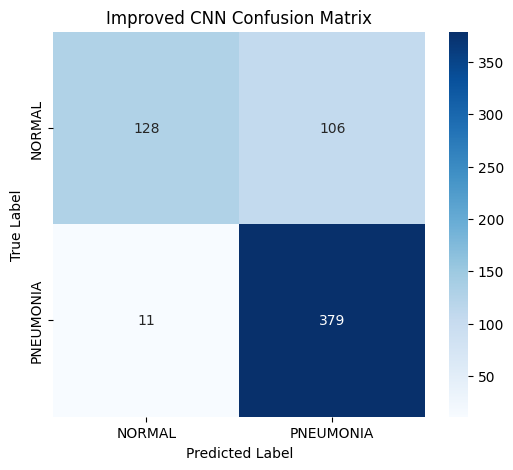

In [ ]:
# ============================================================
# CONFUSION MATRICES FROM LOCKED RUN
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "Improved CNN Confusion Matrix"
)

plt.show()

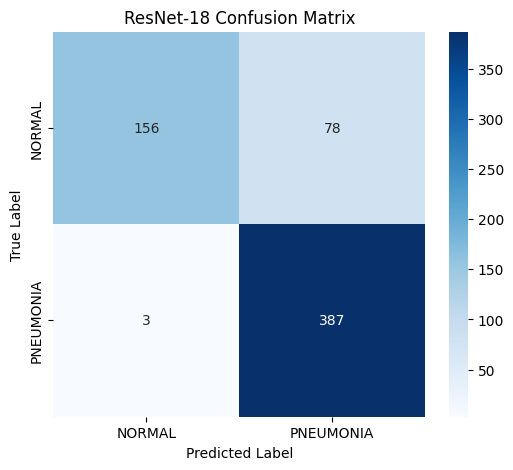

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=test_dataset.classes,
    yticklabels=test_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "ResNet-18 Confusion Matrix"
)

plt.show()

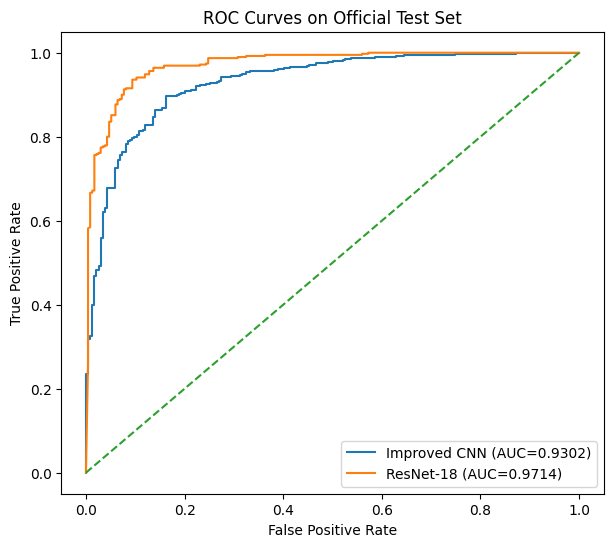

In [ ]:
# ============================================================
# ROC CURVES FROM LOCKED RUN
# ============================================================

cnn_fpr, cnn_tpr, _ = roc_curve(
    cnn_y_true,
    cnn_y_prob
)

resnet_fpr, resnet_tpr, _ = roc_curve(
    resnet_y_true,
    resnet_y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    cnn_fpr,
    cnn_tpr,
    label=(
        f"Improved CNN "
        f"(AUC={cnn_metrics['roc_auc']:.4f})"
    )
)

plt.plot(
    resnet_fpr,
    resnet_tpr,
    label=(
        f"ResNet-18 "
        f"(AUC={resnet_metrics['roc_auc']:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves on Official Test Set"
)

plt.legend()

plt.show()

In [ ]:
# ============================================================
# BOOTSTRAP 95% CONFIDENCE INTERVALS
# ============================================================

def bootstrap_metric_ci(
    y_true,
    y_pred,
    y_prob,
    metric_function,
    n_bootstrap=2000,
    seed=SEED
):
    rng = np.random.default_rng(
        seed
    )

    values = []

    n_samples = len(y_true)

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n_samples,
            size=n_samples
        )

        yt = y_true[indices]
        yp = y_pred[indices]
        ypr = y_prob[indices]

        if len(np.unique(yt)) < 2:
            continue

        try:
            value = metric_function(
                yt,
                yp,
                ypr
            )

            values.append(
                value
            )

        except Exception:
            continue

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return lower, upper

In [ ]:
def bootstrap_accuracy(
    y_true,
    y_pred,
    y_prob
):
    return accuracy_score(
        y_true,
        y_pred
    )


def bootstrap_sensitivity(
    y_true,
    y_pred,
    y_prob
):
    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred
        ).ravel()
    )

    return tp / (tp + fn)


def bootstrap_specificity(
    y_true,
    y_pred,
    y_prob
):
    tn, fp, fn, tp = (
        confusion_matrix(
            y_true,
            y_pred
        ).ravel()
    )

    return tn / (tn + fp)


def bootstrap_f1(
    y_true,
    y_pred,
    y_prob
):
    return f1_score(
        y_true,
        y_pred
    )


def bootstrap_auc(
    y_true,
    y_pred,
    y_prob
):
    return roc_auc_score(
        y_true,
        y_prob
    )

In [ ]:
metric_functions = {
    "Accuracy":
        bootstrap_accuracy,

    "Sensitivity":
        bootstrap_sensitivity,

    "Specificity":
        bootstrap_specificity,

    "F1":
        bootstrap_f1,

    "ROC-AUC":
        bootstrap_auc
}

ci_rows = []

for model_name, y_true, y_pred, y_prob in [
    (
        "Improved CNN",
        cnn_y_true,
        cnn_y_pred,
        cnn_y_prob
    ),
    (
        "ResNet-18",
        resnet_y_true,
        resnet_y_pred,
        resnet_y_prob
    )
]:

    for metric_name, function in (
        metric_functions.items()
    ):

        lower, upper = (
            bootstrap_metric_ci(
                y_true,
                y_pred,
                y_prob,
                function
            )
        )

        ci_rows.append({
            "Model":
                model_name,

            "Metric":
                metric_name,

            "CI Lower":
                lower,

            "CI Upper":
                upper
        })

classification_ci_df = (
    pd.DataFrame(ci_rows)
)

display(
    classification_ci_df
)

,Model,Metric,CI Lower,CI Upper
0,Improved CNN,Accuracy,0.783614,0.842949
1,Improved CNN,Sensitivity,0.954196,0.987246
2,Improved CNN,Specificity,0.486842,0.609652
3,Improved CNN,F1,0.842471,0.889625
4,Improved CNN,ROC-AUC,0.909948,0.949108
5,ResNet-18,Accuracy,0.844551,0.895873
6,ResNet-18,Sensitivity,0.982234,1.000000
7,ResNet-18,Specificity,0.605763,0.727273
8,ResNet-18,F1,0.884615,0.925890
9,ResNet-18,ROC-AUC,0.957767,0.982624


# Calibration Analysis

In [ ]:
# ============================================================
# EXPECTED CALIBRATION ERROR
# ============================================================

def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            mask = (
                (y_prob >= lower)
                &
                (y_prob <= upper)
            )
        else:
            mask = (
                (y_prob > lower)
                &
                (y_prob <= upper)
            )

        if mask.sum() == 0:
            continue

        observed_frequency = (
            y_true[mask].mean()
        )

        mean_probability = (
            y_prob[mask].mean()
        )

        ece += (
            mask.mean()
            *
            abs(
                observed_frequency
                -
                mean_probability
            )
        )

    return ece

In [ ]:
cnn_ece = expected_calibration_error(
    cnn_y_true,
    cnn_y_prob
)

resnet_ece = expected_calibration_error(
    resnet_y_true,
    resnet_y_prob
)

print(
    "Improved CNN Brier:",
    cnn_metrics["brier_score"]
)

print(
    "Improved CNN ECE:",
    cnn_ece
)

print(
    "ResNet-18 Brier:",
    resnet_metrics["brier_score"]
)

print(
    "ResNet-18 ECE:",
    resnet_ece
)

Improved CNN Brier: 0.13494040911326066
Improved CNN ECE: 0.12991756637795612
ResNet-18 Brier: 0.10532108417576214
ResNet-18 ECE: 0.1256087803556464


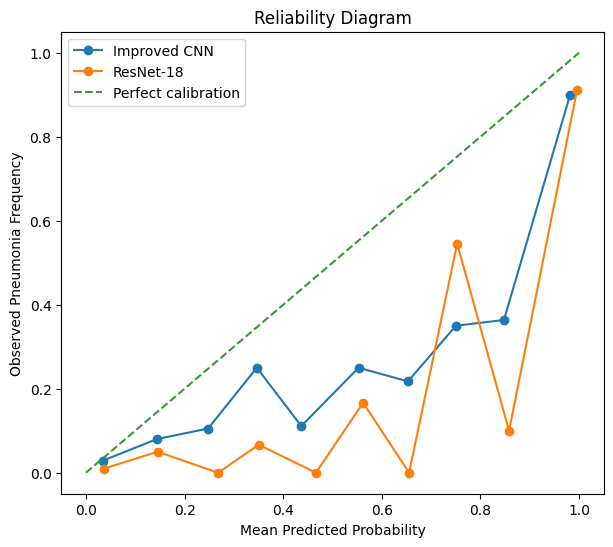

In [ ]:
from sklearn.calibration import (
    calibration_curve
)

cnn_prob_true, cnn_prob_pred = (
    calibration_curve(
        cnn_y_true,
        cnn_y_prob,
        n_bins=10,
        strategy="uniform"
    )
)

resnet_prob_true, resnet_prob_pred = (
    calibration_curve(
        resnet_y_true,
        resnet_y_prob,
        n_bins=10,
        strategy="uniform"
    )
)

plt.figure(figsize=(7, 6))

plt.plot(
    cnn_prob_pred,
    cnn_prob_true,
    marker="o",
    label="Improved CNN"
)

plt.plot(
    resnet_prob_pred,
    resnet_prob_true,
    marker="o",
    label="ResNet-18"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Pneumonia Frequency"
)

plt.title(
    "Reliability Diagram"
)

plt.legend()
plt.show()

In [ ]:
# ============================================================
# PAIRED MODEL COMPARISON - MCNEMAR TEST
# ============================================================

from statsmodels.stats.contingency_tables import (
    mcnemar
)

cnn_correct = (
    cnn_y_pred
    ==
    cnn_y_true
)

resnet_correct = (
    resnet_y_pred
    ==
    resnet_y_true
)

mcnemar_table = np.array([
    [
        np.sum(
            cnn_correct
            &
            resnet_correct
        ),

        np.sum(
            cnn_correct
            &
            ~resnet_correct
        )
    ],
    [
        np.sum(
            ~cnn_correct
            &
            resnet_correct
        ),

        np.sum(
            ~cnn_correct
            &
            ~resnet_correct
        )
    ]
])

print(
    "McNemar table:"
)

print(
    mcnemar_table
)

mcnemar_result = mcnemar(
    mcnemar_table,
    exact=True
)

print(
    "McNemar statistic:",
    mcnemar_result.statistic
)

print(
    "McNemar p-value:",
    mcnemar_result.pvalue
)

McNemar table:
[[493  14]
 [ 50  67]]
McNemar statistic: 14.0
McNemar p-value: 7.069487542545679e-06


In [ ]:
# ============================================================
# SAVE CLASSIFICATION ARTIFACTS
# ============================================================

classification_results_path = (
    f"classification_results_{RUN_ID}.csv"
)

classification_results_df.to_csv(
    classification_results_path,
    index=False
)

classification_ci_df.to_csv(
    f"classification_ci_{RUN_ID}.csv",
    index=False
)

test_predictions_df = pd.DataFrame({
    "true_label":
        resnet_y_true,

    "cnn_prediction":
        cnn_y_pred,

    "cnn_pneumonia_probability":
        cnn_y_prob,

    "resnet_prediction":
        resnet_y_pred,

    "resnet_pneumonia_probability":
        resnet_y_prob
})

test_predictions_df.to_csv(
    f"test_predictions_{RUN_ID}.csv",
    index=False
)

print(
    "Scientific classification artifacts saved."
)

Scientific classification artifacts saved.


In [ ]:
# ============================================================
# CHECKPOINT SHA-256 HASHES
# ============================================================

def file_sha256(
    filepath
):
    sha256 = hashlib.sha256()

    with open(
        filepath,
        "rb"
    ) as file:

        for block in iter(
            lambda: file.read(
                1024 * 1024
            ),
            b""
        ):
            sha256.update(block)

    return sha256.hexdigest()


cnn_checkpoint_sha256 = (
    file_sha256(
        best_cnn_checkpoint
    )
)

resnet_checkpoint_sha256 = (
    file_sha256(
        best_resnet_checkpoint
    )
)

print(
    "Improved CNN SHA-256:",
    cnn_checkpoint_sha256
)

print(
    "ResNet-18 SHA-256:",
    resnet_checkpoint_sha256
)

Improved CNN SHA-256: ddecb2b37c7450ee02f4a5f1cafb842c29a13fe899d0149efdcf6befad70dfad
ResNet-18 SHA-256: 6f600af0c45f9cf62ed7bba2785c2cc9d075b0737a400b139b6522e3df31dc2e


In [ ]:
# ============================================================
# RUN MANIFEST
# ============================================================

run_manifest = {
    "run_id":
        RUN_ID,

    "seed":
        SEED,

    "device":
        str(device),

    "pytorch_version":
        torch.__version__,

    "cuda_version":
        torch.version.cuda,

    "dataset": {
        "internal_train":
            len(internal_train_dataset),

        "internal_validation":
            len(internal_val_dataset),

        "original_validation":
            len(original_val_dataset),

        "official_test":
            len(test_dataset)
    },

    "training": {
        "batch_size":
            batch_size,

        "epochs":
            num_epochs,

        "optimizer":
            "Adam",

        "learning_rate":
            1e-4,

        "loss":
            "Weighted cross-entropy"
    },

    "models": {
    "improved_cnn_checkpoint":
        best_cnn_checkpoint,

    "improved_cnn_checkpoint_sha256":
        cnn_checkpoint_sha256,

    "resnet18_checkpoint":
        best_resnet_checkpoint,

    "resnet18_checkpoint_sha256":
        resnet_checkpoint_sha256,

    "resnet_pretrained_weights":
        "ResNet18_Weights.DEFAULT"
}
}

run_manifest_path = (
    f"run_manifest_{RUN_ID}.json"
)

with open(
    run_manifest_path,
    "w"
) as file:

    json.dump(
        run_manifest,
        file,
        indent=4
    )

print(
    "Saved:",
    run_manifest_path
)

Saved: run_manifest_20260827_103144.json


In [ ]:
# ============================================================
# SAVE EXACT PYTHON ENVIRONMENT
# ============================================================

import subprocess

environment_path = (
    f"environment_{RUN_ID}.txt"
)

with open(
    environment_path,
    "w"
) as file:

    subprocess.run(
        [
            "pip",
            "freeze"
        ],
        stdout=file,
        text=True
    )

print(
    "Saved:",
    environment_path
)

Saved: environment_20260827_103144.txt


# GRAD-CAM (Explanation Agent)

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=4a2a6c854db103397ba445438876ed757cbb4e14f75117257280a706d2d855b7
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
#Model
model = SimpleCNNImproved().to(device)
model.load_state_dict(torch.load("best_simple_cnn_weighted.pth", map_location=device))
model.eval()

SimpleCNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [ ]:
#Target layer seçimi
#Grad-CAM son convolution katmanını kullanır.

target_layer = model.features[6] #features[6] = son Conv2d katmanı

In [ ]:
#Test görüntüsü al
import random

img_path, label = random.choice(test_dataset.samples)
print("Gerçek sınıf:", test_dataset.classes[label])

image = Image.open(img_path).convert("RGB")

Gerçek sınıf: NORMAL


In [ ]:
#Görüntüyü modele hazırla
input_tensor = test_transform(image).unsqueeze(0).to(device)

In [ ]:
#Model tahmini
output = model(input_tensor)
_, pred = torch.max(output, 1)

pred_class = pred.item()
print("Model tahmini:", test_dataset.classes[pred_class])

Model tahmini: NORMAL


In [ ]:
#Grad-CAM oluştur
cam = GradCAM(model=model, target_layers=[target_layer])

targets = [ClassifierOutputTarget(pred_class)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]

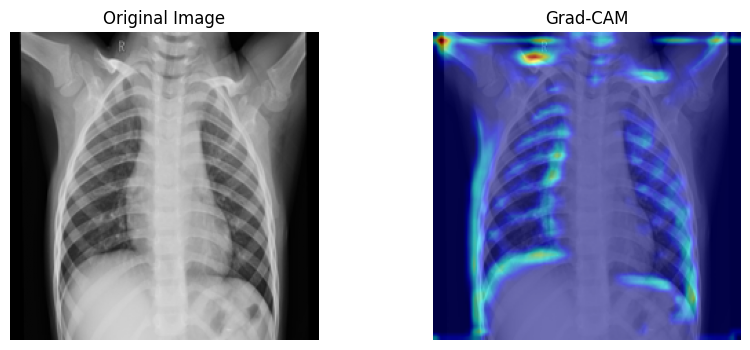

In [ ]:
#Görselleştir
import numpy as np

# Görüntüyü numpy formatına çevir
image_np = np.array(image.resize((224, 224))) / 255.0

cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cam_image)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

# SHAP Explanation Agent

In [ ]:
!pip install shap

In [ ]:
import shap
import numpy as np
import torch
import matplotlib.pyplot as plt

In [ ]:
#SHAP için en iyi ResNet-18 modelini kullan
best_resnet18.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
# Background data seç
background_images, background_labels = next(
    iter(internal_train_loader)
)

background_images = background_images[:5].to(device)

print("Background shape:", background_images.shape)

Background shape: torch.Size([5, 3, 224, 224])


In [ ]:
#Açıklanacak test görüntülerini seç
test_images, test_labels = next(iter(test_loader))

test_images = test_images[:2].to(device)
test_labels = test_labels[:2]

print("Test images shape:", test_images.shape)
print("True labels:", test_labels)

Test images shape: torch.Size([2, 3, 224, 224])
True labels: tensor([0, 0])


In [ ]:
#SHAP GradientExplainer oluştur
explainer = shap.GradientExplainer(best_resnet18, background_images)

In [ ]:
#SHAP değerlerini hesapla
shap_values = explainer.shap_values(test_images)

In [ ]:
#Görselleri SHAP için uygun formata getir
def denormalize_images(images):
    images = images.detach().cpu().numpy()
    images = np.transpose(images, (0, 2, 3, 1))
    images = (images * 0.5) + 0.5
    images = np.clip(images, 0, 1)
    return images

test_images_np = denormalize_images(test_images)

In [ ]:
#SHAP çıktısını düzenle
if isinstance(shap_values, list):
    shap_values_class0 = shap_values[0]
    shap_values_class1 = shap_values[1]
else:
    shap_values_class0 = shap_values[..., 0]
    shap_values_class1 = shap_values[..., 1]

# NCHW -> NHWC
shap_values_class0 = np.transpose(shap_values_class0, (0, 2, 3, 1))
shap_values_class1 = np.transpose(shap_values_class1, (0, 2, 3, 1))

SHAP explanation for NORMAL class


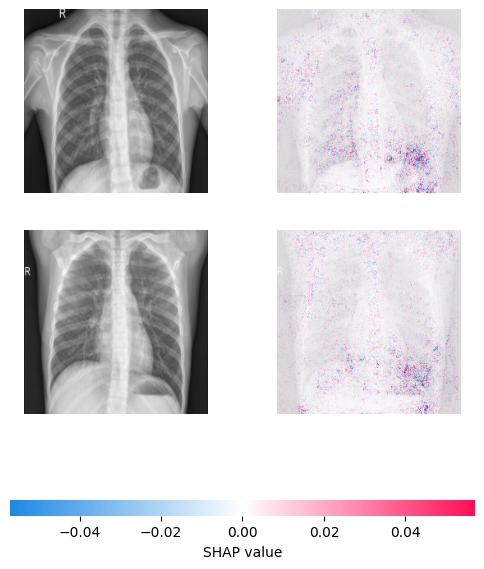

In [ ]:
#SHAP görselleştirme — NORMAL sınıfı
print("SHAP explanation for NORMAL class")
shap.image_plot(shap_values_class0, test_images_np)

SHAP explanation for PNEUMONIA class


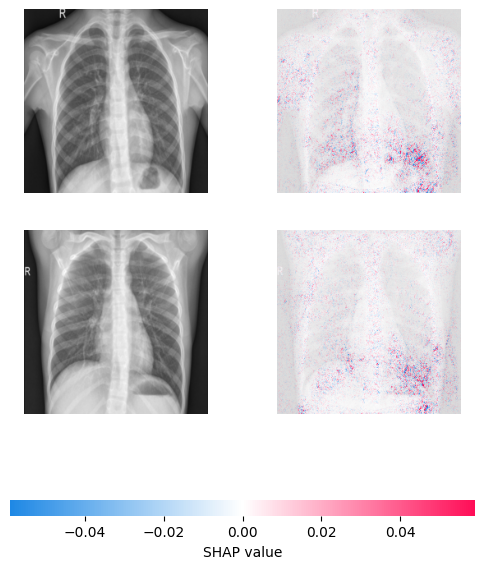

In [ ]:
#SHAP görselleştirme — PNEUMONIA sınıfı
print("SHAP explanation for PNEUMONIA class")
shap.image_plot(shap_values_class1, test_images_np)

In [ ]:
#Tahminleri de yazdır
with torch.no_grad():
    outputs = best_resnet18(test_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

for i in range(len(test_images)):
    print(f"Sample {i+1}")
    print("True Label:", test_dataset.classes[test_labels[i].item()])
    print("Predicted Label:", test_dataset.classes[preds[i].item()])
    print("Confidence:", probs[i, preds[i]].item())
    print("-" * 40)

Sample 1
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.9869633316993713
----------------------------------------
Sample 2
True Label: NORMAL
Predicted Label: NORMAL
Confidence: 0.8544582724571228
----------------------------------------


Grad-Cam vs SHAP

| Özellik          | Grad-CAM           | SHAP        |
| ---------------- | ------------------ | ----------- |
| Açıklama tipi    | Spatial (bölgesel) | Pixel-level |
| Görsellik        | Net heatmap        | Gürültülü   |
| Medikal uygunluk | ✔ yüksek           | ❌ düşük   |
| Interpretability | Kolay              | Zor         |


### SHAP as a Separate Qualitative Illustration

SHAP is retained only as a separate qualitative visualization of pixel-level contribution patterns. No quantitative or clinical superiority claim is made between SHAP and Grad-CAM. Grad-CAM is used in the exploratory spatial analysis because it directly produces a spatial heatmap compatible with the implemented overlap and perturbation analyses.

# CRITIC AGENT (Validation of Explanations)

In [ ]:
# ============================================================
# EXPLORATORY HEURISTIC SPATIAL MASK
# ============================================================

import cv2

def get_heuristic_spatial_mask(
    image
):
    """
    Creates an exploratory intensity-based spatial mask.

    IMPORTANT:
    This is NOT an anatomical lung segmentation,
    NOT a lesion annotation,
    and NOT clinical ground truth.

    It is used only for exploratory spatial
    plausibility analysis.
    """

    img = np.array(
        image
        .resize((224, 224))
        .convert("L")
    )

    _, mask = cv2.threshold(
        img.astype(np.uint8),
        50,
        255,
        cv2.THRESH_BINARY
    )

    mask = (
        mask.astype(np.float32)
        / 255.0
    )

    return mask

In [ ]:
#Grad-CAM’i binary yap
def get_cam_mask(cam, threshold=0.4):
    cam_mask = cam.copy()

    cam_mask[cam_mask < threshold] = 0
    cam_mask[cam_mask >= threshold] = 1

    return cam_mask

In [ ]:
#IoU hesapla
def compute_iou(mask1, mask2):
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    if union == 0:
        return 0

    return intersection / union

In [ ]:
#Hepsini birleştir CELL96
'''lung_mask = get_lung_mask(image)
cam_mask = get_cam_mask(grayscale_cam)

iou = compute_iou(lung_mask, cam_mask)

print("IoU:", iou)'''

'lung_mask = get_lung_mask(image)\ncam_mask = get_cam_mask(grayscale_cam)\n\niou = compute_iou(lung_mask, cam_mask)\n\nprint("IoU:", iou)'

In [ ]:
heuristic_mask = (
    get_heuristic_spatial_mask(
        image
    )
)

cam_mask = get_cam_mask(
    grayscale_cam
)

heuristic_iou = compute_iou(
    heuristic_mask,
    cam_mask
)

print(
    "Exploratory spatial IoU:",
    heuristic_iou
)

Exploratory spatial IoU: 0.018519943568038988


In [ ]:
EXPLORATORY_IOU_THRESHOLD = 0.4

spatial_overlap_flag = (
    "HIGH_OVERLAP"
    if heuristic_iou
    >= EXPLORATORY_IOU_THRESHOLD
    else
    "LOW_OVERLAP"
)

print(
    "Exploratory spatial overlap:",
    spatial_overlap_flag
)

Exploratory spatial overlap: LOW_OVERLAP


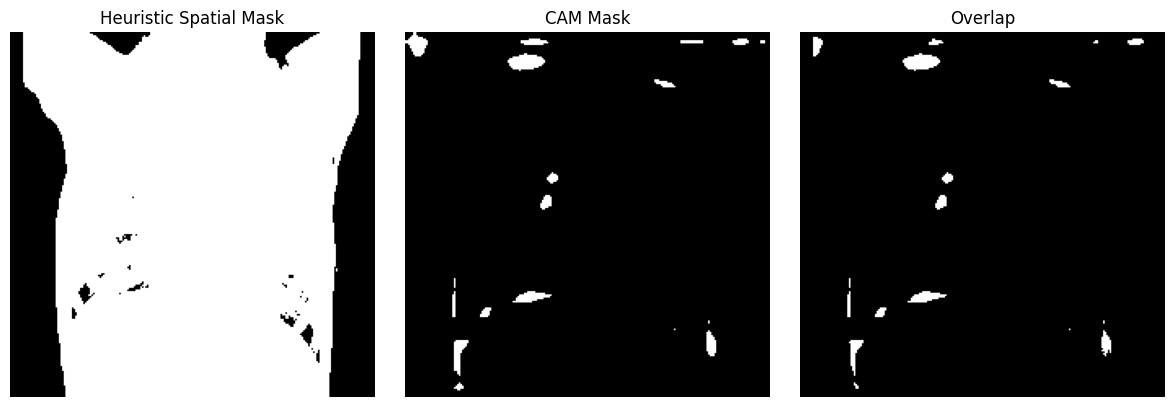

In [ ]:
# ============================================================
# VISUALIZATION: HEURISTIC MASK, CAM MASK AND OVERLAP
# ============================================================

plt.figure(figsize=(12, 4))

# ------------------------------------------------------------
# 1. Heuristic Spatial Mask
# ------------------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    heuristic_mask,
    cmap="gray"
)

plt.title("Heuristic Spatial Mask")

plt.axis("off")


# ------------------------------------------------------------
# 2. CAM Mask
# ------------------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    cam_mask,
    cmap="gray"
)

plt.title("CAM Mask")

plt.axis("off")


# ------------------------------------------------------------
# 3. Overlap between Heuristic Spatial Mask and CAM Mask
# ------------------------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    heuristic_mask * cam_mask,
    cmap="gray"
)

plt.title("Overlap")

plt.axis("off")


plt.tight_layout()
plt.show()

# Additional Exploratory Explainability Metrics

In [ ]:
#Pointing Game
def pointing_game_score(
    grayscale_cam,
    reference_mask
):
    """
    Checks whether the maximum Grad-CAM
    activation point falls inside the
    exploratory reference mask.

    This is not lesion-localization accuracy.
    """

    max_index = np.unravel_index(
        np.argmax(grayscale_cam),
        grayscale_cam.shape
    )

    y, x = max_index

    hit = int(
        reference_mask[y, x] > 0
    )

    return hit, (x, y)

In [ ]:
# ============================================================
# POINTING GAME VISUALIZATION
# ============================================================

def visualize_pointing_game(
    image,
    grayscale_cam,
    reference_mask
):

    # Pointing Game score
    hit, point = pointing_game_score(
        grayscale_cam,
        reference_mask
    )

    # Resize image for visualization
    image_np = (
        np.array(
            image.resize((224, 224))
        ).astype(np.float32)
        / 255.0
    )

    plt.figure(figsize=(10, 4))

    # --------------------------------------------------------
    # 1. Original image + maximum Grad-CAM activation point
    # --------------------------------------------------------

    plt.subplot(1, 2, 1)

    plt.imshow(image_np)

    plt.scatter(
        point[0],
        point[1],
        c="red",
        s=80
    )

    plt.title(
        f"Max CAM Point | Hit={hit}"
    )

    plt.axis("off")


    # --------------------------------------------------------
    # 2. Heuristic Spatial Mask + maximum activation point
    # --------------------------------------------------------

    plt.subplot(1, 2, 2)

    plt.imshow(
        reference_mask,
        cmap="gray"
    )

    plt.scatter(
        point[0],
        point[1],
        c="red",
        s=80
    )

    plt.title(
        "Heuristic Spatial Mask + Max Point"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return hit

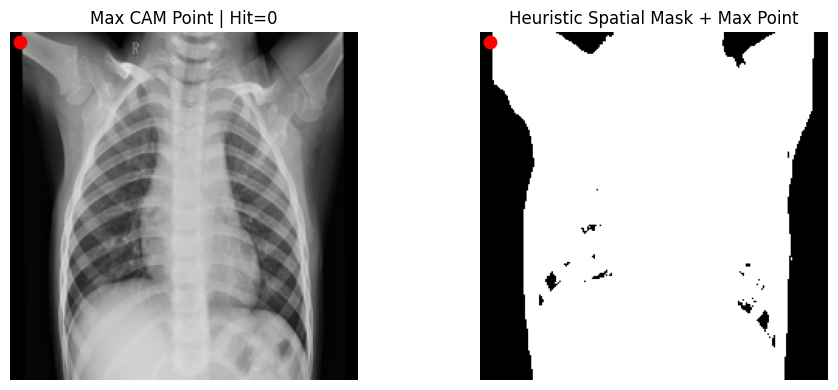

Pointing Game Hit: 0


In [ ]:
# ============================================================
# CREATE HEURISTIC REFERENCE MASK
# ============================================================

reference_mask = get_heuristic_spatial_mask(image)


# ============================================================
# RUN POINTING GAME VISUALIZATION
# ============================================================

hit = visualize_pointing_game(
    image,
    grayscale_cam,
    reference_mask
)

print(
    "Pointing Game Hit:",
    hit
)

In [ ]:
# ============================================================
# POINTING GAME ON 5 TEST SAMPLES
# ============================================================

def run_pointing_game_on_samples(
    selected_samples,
    model,
    target_layer,
    test_transform,
    class_names,
    device
):
    hits = []

    model.eval()

    for idx, (img_path, true_label) in enumerate(selected_samples):

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------
        image = Image.open(img_path).convert("RGB")

        input_tensor = (
            test_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        with torch.no_grad():
            output = model(input_tensor)

        _, pred = torch.max(output, 1)

        pred_class = pred.item()

        # ----------------------------------------------------
        # Grad-CAM
        # ----------------------------------------------------
        cam = GradCAM(
            model=model,
            target_layers=[target_layer]
        )

        targets = [
            ClassifierOutputTarget(pred_class)
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        # ----------------------------------------------------
        # Heuristic reference mask
        # ----------------------------------------------------
        reference_mask = get_heuristic_spatial_mask(
            image
        )

        # ----------------------------------------------------
        # Pointing Game
        # ----------------------------------------------------
        hit, point = pointing_game_score(
            grayscale_cam,
            reference_mask
        )

        hits.append(hit)

        # ----------------------------------------------------
        # Print results
        # ----------------------------------------------------
        print(f"Sample {idx + 1}")

        print(
            "True Label:",
            class_names[true_label]
        )

        print(
            "Predicted Label:",
            class_names[pred_class]
        )

        print(
            "Pointing Game Hit:",
            hit
        )

        print("-" * 40)

        # ----------------------------------------------------
        # Visualization
        # ----------------------------------------------------
        visualize_pointing_game(
            image,
            grayscale_cam,
            reference_mask
        )

    # --------------------------------------------------------
    # Mean Pointing Game hit rate
    # --------------------------------------------------------
    pointing_game_accuracy = np.mean(hits)

    print(
        "Pointing Game Accuracy:",
        pointing_game_accuracy
    )

    return pointing_game_accuracy

Sample 1
True Label: NORMAL
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


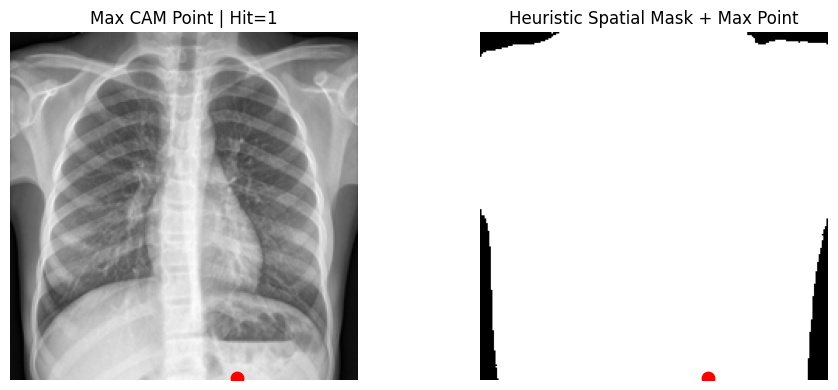

Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Pointing Game Hit: 0
----------------------------------------


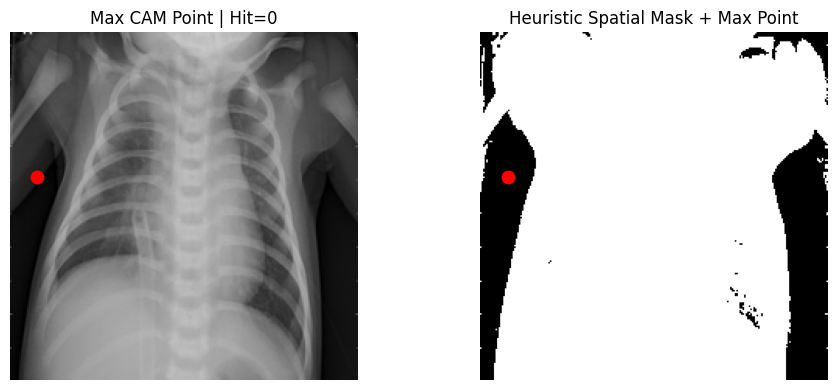

Sample 3
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


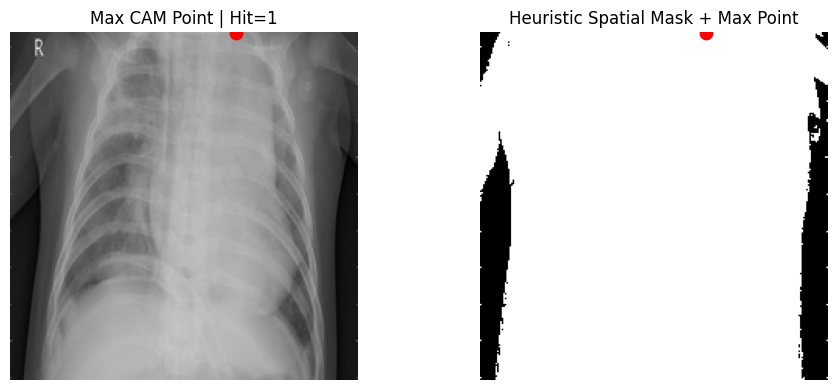

Sample 4
True Label: NORMAL
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


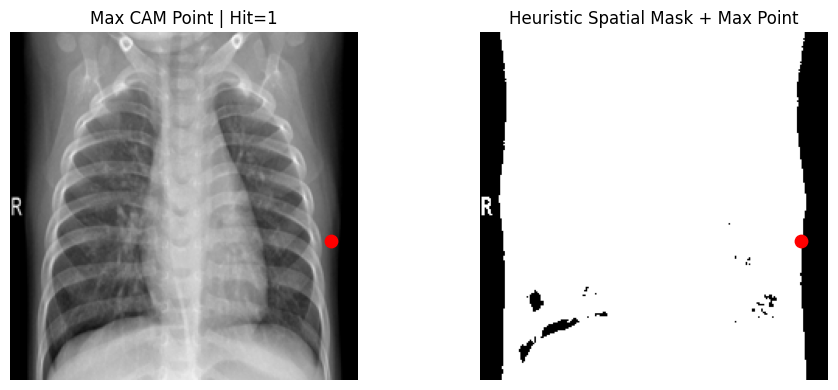

Sample 5
True Label: NORMAL
Predicted Label: PNEUMONIA
Pointing Game Hit: 1
----------------------------------------


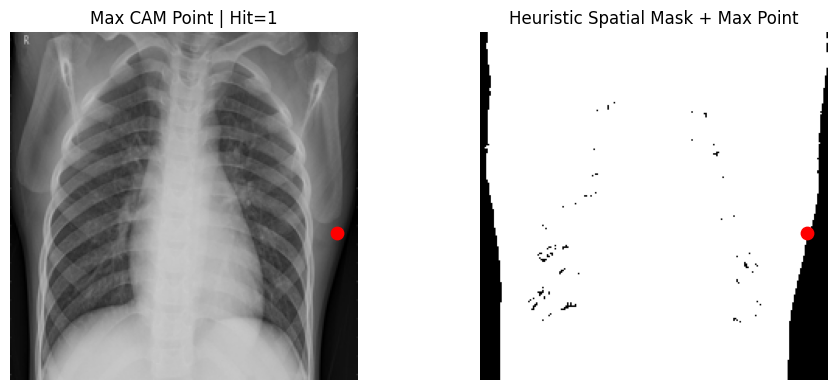

Pointing Game Accuracy: 0.8


In [ ]:
# ============================================================
# SELECT 5 RANDOM TEST SAMPLES
# ============================================================

selected_samples = random.sample(
    test_dataset.samples,
    5
)

# Improved CNN target layer
target_layer = model.features[6]

# ============================================================
# RUN POINTING GAME
# ============================================================

pointing_game_acc = run_pointing_game_on_samples(
    selected_samples,
    model,
    target_layer,
    test_transform,
    test_dataset.classes,
    device
)

In [ ]:
#CAM bölgesini maskeleme fonksiyonu
def mask_important_region(input_tensor, grayscale_cam, threshold=0.4):
    """
    Grad-CAM tarafından önemli bulunan bölgeleri kapatır.
    """
    cam_mask = get_cam_mask(grayscale_cam, threshold=threshold)

    cam_mask_tensor = torch.tensor(cam_mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(input_tensor.device)

    # 1 olan önemli bölgeleri 0 yapıyoruz
    masked_tensor = input_tensor.clone()
    masked_tensor = masked_tensor * (1 - cam_mask_tensor)

    return masked_tensor

In [ ]:
def compute_perturbation_sensitivity(
    model,
    input_tensor,
    grayscale_cam,
    target_class,
    threshold=0.4
):
    """
    Measures the change in predicted-class
    probability after masking the
    Grad-CAM-selected region.

    This is treated as perturbation sensitivity,
    not as definitive causal faithfulness.
    """

    model.eval()

    with torch.no_grad():

        original_output = model(
            input_tensor
        )

        original_probability = (
            torch.softmax(
                original_output,
                dim=1
            )[0, target_class]
            .item()
        )

        masked_tensor = (
            mask_important_region(
                input_tensor,
                grayscale_cam,
                threshold=threshold
            )
        )

        masked_output = model(
            masked_tensor
        )

        masked_probability = (
            torch.softmax(
                masked_output,
                dim=1
            )[0, target_class]
            .item()
        )

    probability_drop = (
        original_probability
        -
        masked_probability
    )

    return (
        original_probability,
        masked_probability,
        probability_drop,
        masked_tensor
    )

In [ ]:
# ============================================================
# PERTURBATION SENSITIVITY VISUALIZATION
# ============================================================

def visualize_perturbation_sensitivity(
    image,
    cam_image,
    masked_tensor,
    original_prob,
    masked_prob,
    probability_drop
):

    # Original image
    image_np = (
        np.array(
            image.resize((224, 224))
        ).astype(np.float32)
        / 255.0
    )

    # Convert masked tensor back to image format
    masked_np = (
        masked_tensor
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    masked_np = np.transpose(
        masked_np,
        (1, 2, 0)
    )

    # Reverse approximate normalization for visualization
    masked_np = (
        masked_np * 0.5
    ) + 0.5

    masked_np = np.clip(
        masked_np,
        0,
        1
    )

    # --------------------------------------------------------
    # Visualization
    # --------------------------------------------------------

    plt.figure(figsize=(14, 4))

    # Original
    plt.subplot(1, 3, 1)

    plt.imshow(image_np)

    plt.title("Original Image")

    plt.axis("off")


    # Grad-CAM
    plt.subplot(1, 3, 2)

    plt.imshow(cam_image)

    plt.title("Grad-CAM")

    plt.axis("off")


    # Perturbed image
    plt.subplot(1, 3, 3)

    plt.imshow(masked_np)

    plt.title(
        f"Perturbed Image\n"
        f"Probability Drop = {probability_drop:.3f}"
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()


    # --------------------------------------------------------
    # Numerical results
    # --------------------------------------------------------

    print(
        f"Original predicted-class probability: "
        f"{original_prob:.4f}"
    )

    print(
        f"Perturbed predicted-class probability: "
        f"{masked_prob:.4f}"
    )

    print(
        f"Probability drop: "
        f"{probability_drop:.4f}"
    )

In [ ]:
# ============================================================
# PERTURBATION SENSITIVITY ON 5 TEST SAMPLES
# ============================================================

def run_perturbation_sensitivity_on_samples(
    selected_samples,
    model,
    target_layer,
    test_transform,
    class_names,
    device,
    cam_threshold=0.4
):

    sensitivity_scores = []

    model.eval()

    for idx, (img_path, true_label) in enumerate(
        selected_samples
    ):

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = Image.open(
            img_path
        ).convert("RGB")

        input_tensor = (
            test_transform(image)
            .unsqueeze(0)
            .to(device)
        )


        # ----------------------------------------------------
        # Model prediction
        # ----------------------------------------------------

        with torch.no_grad():

            output = model(
                input_tensor
            )

        probs = torch.softmax(
            output,
            dim=1
        )

        _, pred = torch.max(
            output,
            1
        )

        pred_class = pred.item()


        # ----------------------------------------------------
        # Grad-CAM
        # ----------------------------------------------------

        cam = GradCAM(
            model=model,
            target_layers=[target_layer]
        )

        targets = [
            ClassifierOutputTarget(
                pred_class
            )
        ]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]


        # ----------------------------------------------------
        # Prepare CAM visualization
        # ----------------------------------------------------

        image_np = (
            np.array(
                image.resize((224, 224))
            ).astype(np.float32)
            / 255.0
        )

        cam_image = show_cam_on_image(
            image_np,
            grayscale_cam,
            use_rgb=True
        )


        # ----------------------------------------------------
        # Perturbation sensitivity
        # ----------------------------------------------------

        (
            original_prob,
            masked_prob,
            probability_drop,
            masked_tensor
        ) = compute_perturbation_sensitivity(

            model=model,

            input_tensor=input_tensor,

            grayscale_cam=grayscale_cam,

            target_class=pred_class,

            threshold=cam_threshold
        )


        sensitivity_scores.append(
            probability_drop
        )


        # ----------------------------------------------------
        # Print sample results
        # ----------------------------------------------------

        print(
            f"Sample {idx + 1}"
        )

        print(
            "True Label:",
            class_names[
                true_label
            ]
        )

        print(
            "Predicted Label:",
            class_names[
                pred_class
            ]
        )

        print(
            f"Original predicted-class probability: "
            f"{original_prob:.4f}"
        )

        print(
            f"Perturbed predicted-class probability: "
            f"{masked_prob:.4f}"
        )

        print(
            f"Probability Drop: "
            f"{probability_drop:.4f}"
        )

        print("-" * 50)


        # ----------------------------------------------------
        # Visualization
        # ----------------------------------------------------

        visualize_perturbation_sensitivity(

            image=image,

            cam_image=cam_image,

            masked_tensor=masked_tensor,

            original_prob=original_prob,

            masked_prob=masked_prob,

            probability_drop=probability_drop
        )


    # --------------------------------------------------------
    # Mean perturbation sensitivity
    # --------------------------------------------------------

    mean_sensitivity = np.mean(
        sensitivity_scores
    )

    print(
        "Mean Perturbation Sensitivity:",
        mean_sensitivity
    )

    return mean_sensitivity

Sample 1
True Label: NORMAL
Predicted Label: NORMAL
Original predicted-class probability: 0.8113
Perturbed predicted-class probability: 0.5921
Probability Drop: 0.2193
--------------------------------------------------


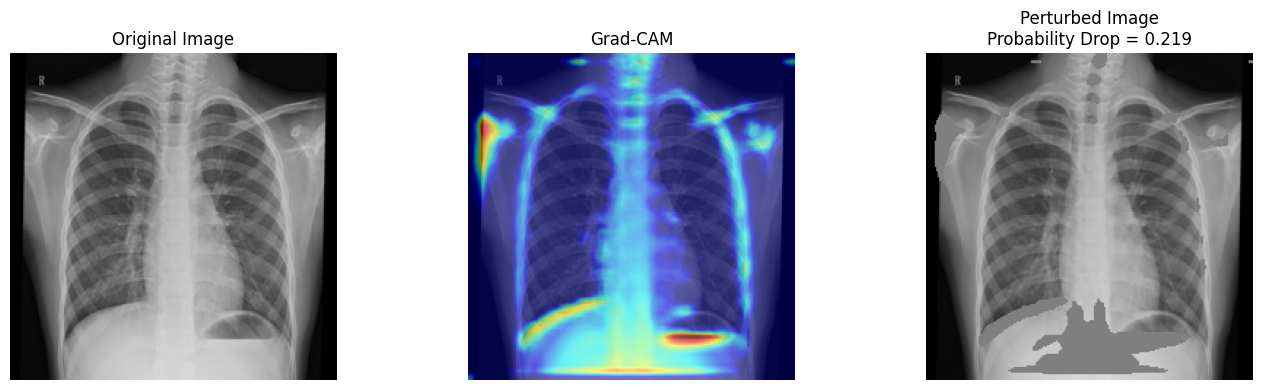

Original predicted-class probability: 0.8113
Perturbed predicted-class probability: 0.5921
Probability drop: 0.2193
Sample 2
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original predicted-class probability: 0.9661
Perturbed predicted-class probability: 0.3518
Probability Drop: 0.6143
--------------------------------------------------


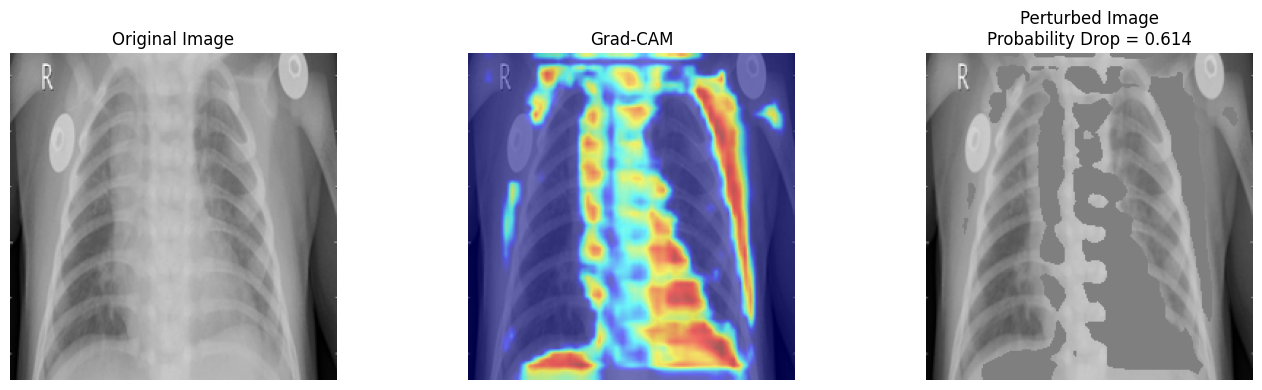

Original predicted-class probability: 0.9661
Perturbed predicted-class probability: 0.3518
Probability drop: 0.6143
Sample 3
True Label: NORMAL
Predicted Label: PNEUMONIA
Original predicted-class probability: 0.8253
Perturbed predicted-class probability: 0.5913
Probability Drop: 0.2340
--------------------------------------------------


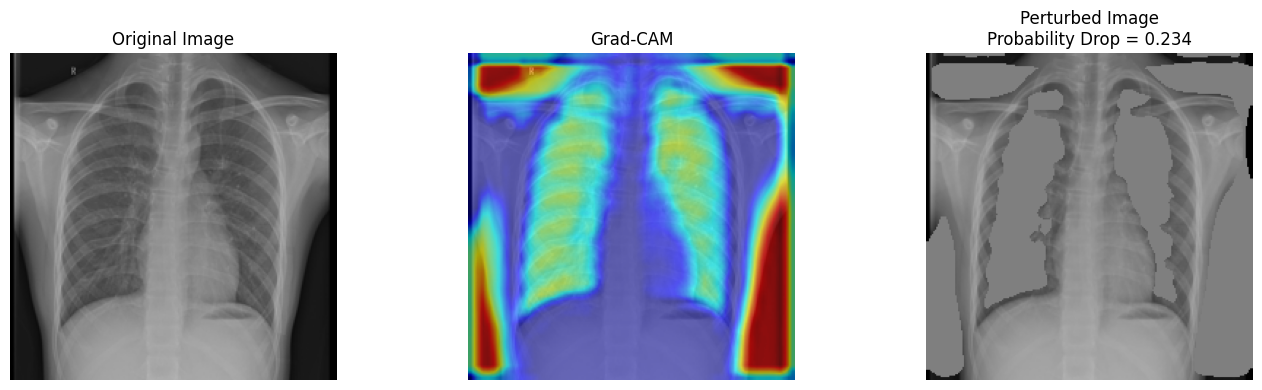

Original predicted-class probability: 0.8253
Perturbed predicted-class probability: 0.5913
Probability drop: 0.2340
Sample 4
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original predicted-class probability: 0.9995
Perturbed predicted-class probability: 0.9995
Probability Drop: 0.0000
--------------------------------------------------


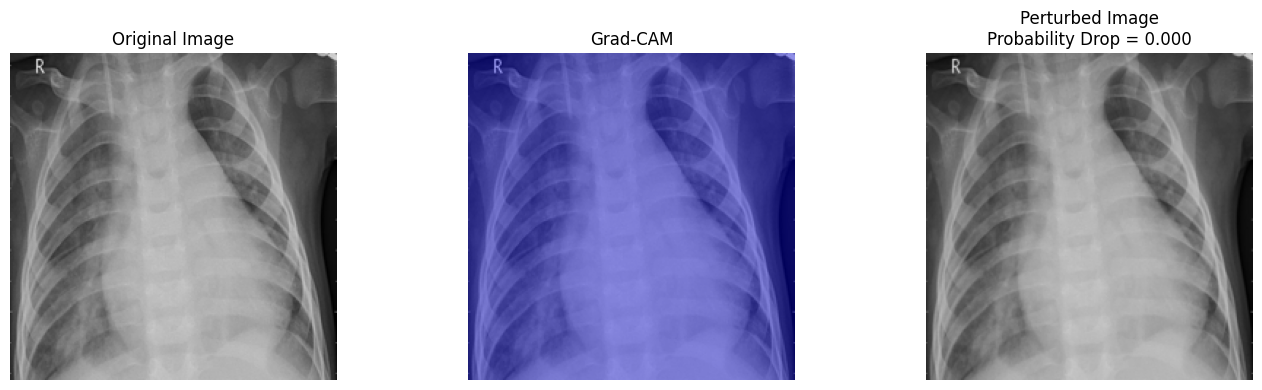

Original predicted-class probability: 0.9995
Perturbed predicted-class probability: 0.9995
Probability drop: 0.0000
Sample 5
True Label: PNEUMONIA
Predicted Label: PNEUMONIA
Original predicted-class probability: 0.9970
Perturbed predicted-class probability: 0.9970
Probability Drop: 0.0000
--------------------------------------------------


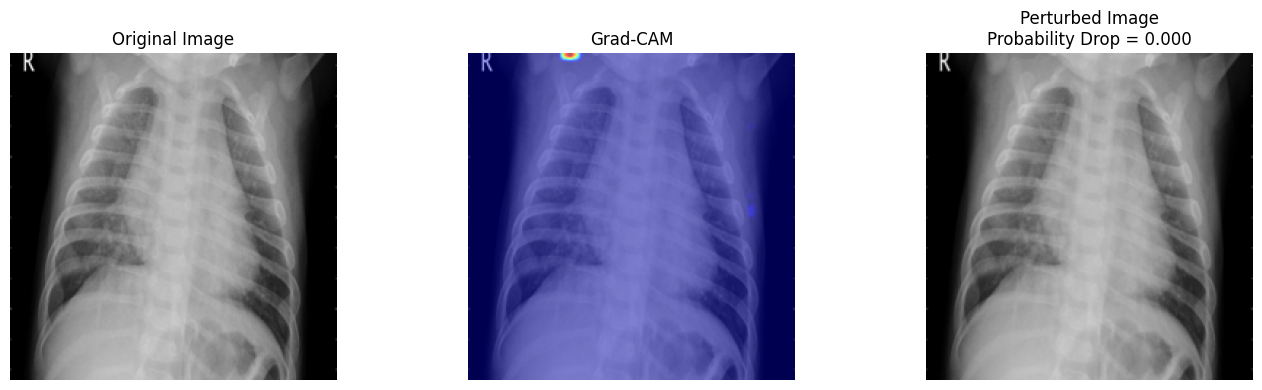

Original predicted-class probability: 0.9970
Perturbed predicted-class probability: 0.9970
Probability drop: 0.0000
Mean Perturbation Sensitivity: 0.21350575089454651
Final Mean Perturbation Sensitivity: 0.21350575089454651


In [ ]:
# ============================================================
# RUN PERTURBATION SENSITIVITY ON 5 RANDOM TEST SAMPLES
# ============================================================

selected_samples = random.sample(
    test_dataset.samples,
    5
)

target_layer = model.features[6]

mean_sensitivity = (
    run_perturbation_sensitivity_on_samples(
        selected_samples=selected_samples,
        model=model,
        target_layer=target_layer,
        test_transform=test_transform,
        class_names=test_dataset.classes,
        device=device,
        cam_threshold=0.4
    )
)

print(
    "Final Mean Perturbation Sensitivity:",
    mean_sensitivity
)

# LLM-Based Multi-Agent Layer

In [ ]:
# ============================================================
# OPTIONAL LLM SOFTWARE DEMONSTRATION SETTINGS
# ============================================================

USE_LIVE_LLM = False

print(
    "Live Gemini enabled:",
    USE_LIVE_LLM
)

Live Gemini enabled: False


In [ ]:
#!pip install -q google-generativeai

In [ ]:
#Gemini bağlantısı
import google.generativeai as genai
from google.colab import userdata

genai.configure(api_key=userdata.get("GEMINI_API_KEY"))

#model = genai.GenerativeModel("gemini-1.5-flash")
model = genai.GenerativeModel("models/gemini-3.5-flash")

print("Gemini connected successfully!")

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini connected successfully!


In [ ]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.6-preview
models/gemini-robotics-er-2-preview
mod

In [ ]:
if USE_LIVE_LLM:

    response = model.generate_content(
        "Briefly explain the role of "
        "explainability in medical AI."
    )

    print(response.text)

else:
    print(
        "Live LLM test skipped."
    )

Live LLM test skipped.


In [ ]:
#Sonra LLM agent’lara bunların çıktısını vereceğiz.
def run_vision_tool(image_path):
    """
    Vision Tool:
    Verilen X-ray görüntüsünü ResNet-18 modeliyle sınıflandırır.
    Çıktı olarak prediction ve confidence döndürür.
    """
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    best_resnet18.eval()

    with torch.no_grad():
        outputs = best_resnet18(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    return {
        "prediction": test_dataset.classes[pred],
        "confidence": round(confidence, 4)
    }

In [ ]:
#Sonra test etmek için:
sample_path, sample_label = random.choice(test_dataset.samples)

vision_result = run_vision_tool(sample_path)
print("True label:", test_dataset.classes[sample_label])
print(vision_result)

True label: NORMAL
{'prediction': 'NORMAL', 'confidence': 0.9969}


**1. Explanation Tool**

In [ ]:
def run_explanation_tool(image_path, cam_threshold=0.4):
    """
    Explanation Tool:
    Verilen X-ray görüntüsü için ResNet-18 modelinin Grad-CAM açıklamasını üretir.
    """
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transform(image).unsqueeze(0).to(device)

    best_resnet18.eval()

    with torch.no_grad():
        outputs = best_resnet18(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    # ResNet-18 için son convolution layer
    target_layer = best_resnet18.layer4[-1]

    cam = GradCAM(model=best_resnet18, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(pred)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    image_np = np.array(image.resize((224, 224))) / 255.0
    cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)

    cam_mask = get_cam_mask(grayscale_cam, threshold=cam_threshold)

    return {
        "image": image,
        "input_tensor": input_tensor,
        "prediction": test_dataset.classes[pred],
        "confidence": round(confidence, 4),
        "grayscale_cam": grayscale_cam,
        "cam_image": cam_image,
        "cam_mask": cam_mask,
        "pred_class_idx": pred
    }

Prediction: NORMAL
Confidence: 0.9969


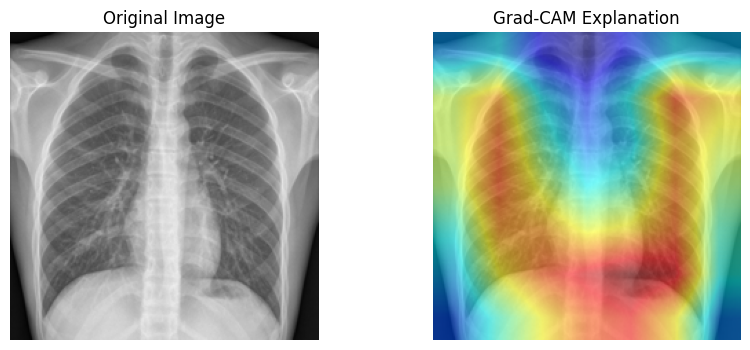

In [ ]:
explanation_result = run_explanation_tool(sample_path)

print("Prediction:", explanation_result["prediction"])
print("Confidence:", explanation_result["confidence"])

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.array(explanation_result["image"].resize((224, 224))) / 255.0)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(explanation_result["cam_image"])
plt.title("Grad-CAM Explanation")
plt.axis("off")

plt.show()

**2. Validation Tool**

Şimdi Critic Agent’ın kullanacağı sayısal validation tool’unu yazıyoruz.

In [ ]:
# ============================================================
# DETERMINISTIC MULTI-METRIC CRITIC GATE
# ============================================================

def deterministic_critic_gate(
    spatial_iou,
    pointing_game_hit,
    perturbation_probability_drop,
    iou_threshold=0.4,
    min_probability_drop=0.0
):
    """
    Experimental deterministic gate.

    IMPORTANT:
    This is not a clinical validation criterion.
    It only flags explanations that fail one or
    more predefined exploratory checks.
    """

    checks = {
        "spatial_overlap":
            spatial_iou
            >= iou_threshold,

        "pointing_game":
            pointing_game_hit
            == 1,

        "positive_perturbation_response":
            perturbation_probability_drop
            > min_probability_drop
    }

    all_passed = all(
        checks.values()
    )

    decision = (
        "PASS"
        if all_passed
        else
        "FLAG"
    )

    return {
        "decision":
            decision,

        "checks":
            checks
    }

In [ ]:
def run_validation_tool(
    image_path,
    cam_threshold=0.4,
    iou_threshold=0.4
):
    """
    Runs exploratory Grad-CAM checks.

    Outputs:
    - exploratory spatial IoU
    - Pointing Game hit on heuristic mask
    - perturbation probability drop
    - deterministic Critic gate result

    None of these metrics are treated as
    clinical explanation ground truth.
    """

    explanation_result = (
        run_explanation_tool(
            image_path,
            cam_threshold
        )
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = (
        test_transform(image)
        .unsqueeze(0)
        .to(device)
    )

    grayscale_cam = (
        explanation_result[
            "grayscale_cam"
        ]
    )

    cam_mask = (
        explanation_result[
            "cam_mask"
        ]
    )

    heuristic_mask = (
        get_heuristic_spatial_mask(
            image
        )
    )

    spatial_iou = compute_iou(
        heuristic_mask,
        cam_mask
    )

    pointing_game_hit, max_point = (
        pointing_game_score(
            grayscale_cam,
            heuristic_mask
        )
    )

    target_class = (
        explanation_result[
            "pred_class_idx"
        ]
    )

    (
        original_probability,
        masked_probability,
        probability_drop,
        masked_tensor
    ) = compute_perturbation_sensitivity(
        model=best_resnet18,
        input_tensor=input_tensor,
        grayscale_cam=grayscale_cam,
        target_class=target_class,
        threshold=cam_threshold
    )

    critic_gate = (
        deterministic_critic_gate(
            spatial_iou=spatial_iou,
            pointing_game_hit=pointing_game_hit,
            perturbation_probability_drop=
                probability_drop,
            iou_threshold=
                iou_threshold
        )
    )

    return {
        "prediction":
            explanation_result[
                "prediction"
            ],

        "predicted_probability":
            explanation_result[
                "confidence"
            ],

        "spatial_iou":
            float(
                spatial_iou
            ),

        "pointing_game_hit":
            int(
                pointing_game_hit
            ),

        "perturbation_probability_drop":
            float(
                probability_drop
            ),

        "original_probability":
            float(
                original_probability
            ),

        "masked_probability":
            float(
                masked_probability
            ),

        "critic_gate":
            critic_gate[
                "decision"
            ],

        "critic_checks":
            critic_gate[
                "checks"
            ],

        "heuristic_mask":
            heuristic_mask,

        "cam_mask":
            cam_mask,

        "overlap":
            heuristic_mask
            * cam_mask,

        "cam_image":
            explanation_result[
                "cam_image"
            ],

        "grayscale_cam":
            grayscale_cam,

        "masked_tensor":
            masked_tensor,

        "max_point":
            max_point
    }

In [ ]:
validation_result = run_validation_tool(sample_path)

print(validation_result)

{'prediction': 'NORMAL', 'predicted_probability': 0.9969, 'spatial_iou': 0.7345373115760228, 'pointing_game_hit': 1, 'perturbation_probability_drop': 0.9704811442643404, 'original_probability': 0.9969203472137451, 'masked_probability': 0.026439202949404716, 'critic_gate': 'PASS', 'critic_checks': {'spatial_overlap': np.True_, 'pointing_game': True, 'positive_perturbation_response': True}, 'heuristic_mask': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'cam_mask': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), 'overlap': array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0.,

Validation sonuçlarını görselleştir:

In [ ]:
# ============================================================
# VISUALIZE VALIDATION RESULT
# ============================================================

def visualize_validation_result(
    image_path,
    validation_result
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_np = (
        np.array(
            image.resize((224, 224))
        ).astype(np.float32)
        / 255.0
    )

    # --------------------------------------------------------
    # Safely obtain optional values
    # --------------------------------------------------------

    iou_value = validation_result.get(
        "iou",
        validation_result.get("iou_score", None)
    )

    decision_value = validation_result.get(
        "iou_decision",
        validation_result.get("decision", "")
    )

    plt.figure(figsize=(16, 4))

    # --------------------------------------------------------
    # 1. Original
    # --------------------------------------------------------

    plt.subplot(1, 5, 1)

    plt.imshow(image_np)

    plt.title("Original")

    plt.axis("off")


    # --------------------------------------------------------
    # 2. Grad-CAM
    # --------------------------------------------------------

    plt.subplot(1, 5, 2)

    plt.imshow(
        validation_result["cam_image"]
    )

    plt.title("Grad-CAM")

    plt.axis("off")


    # --------------------------------------------------------
    # 3. Heuristic Spatial Mask
    # --------------------------------------------------------

    plt.subplot(1, 5, 3)

    plt.imshow(
        validation_result["heuristic_mask"],
        cmap="gray"
    )

    plt.title(
        "Heuristic Spatial Mask"
    )

    plt.axis("off")


    # --------------------------------------------------------
    # 4. CAM Mask
    # --------------------------------------------------------

    plt.subplot(1, 5, 4)

    plt.imshow(
        validation_result["cam_mask"],
        cmap="gray"
    )

    plt.title("CAM Mask")

    plt.axis("off")


    # --------------------------------------------------------
    # 5. Overlap
    # --------------------------------------------------------

    plt.subplot(1, 5, 5)

    plt.imshow(
        validation_result["overlap"],
        cmap="gray"
    )

    if iou_value is not None:

        plt.title(
            f"Overlap\n"
            f"IoU={iou_value:.3f} | "
            f"{decision_value}"
        )

    else:

        plt.title(
            f"Overlap\n"
            f"{decision_value}"
        )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

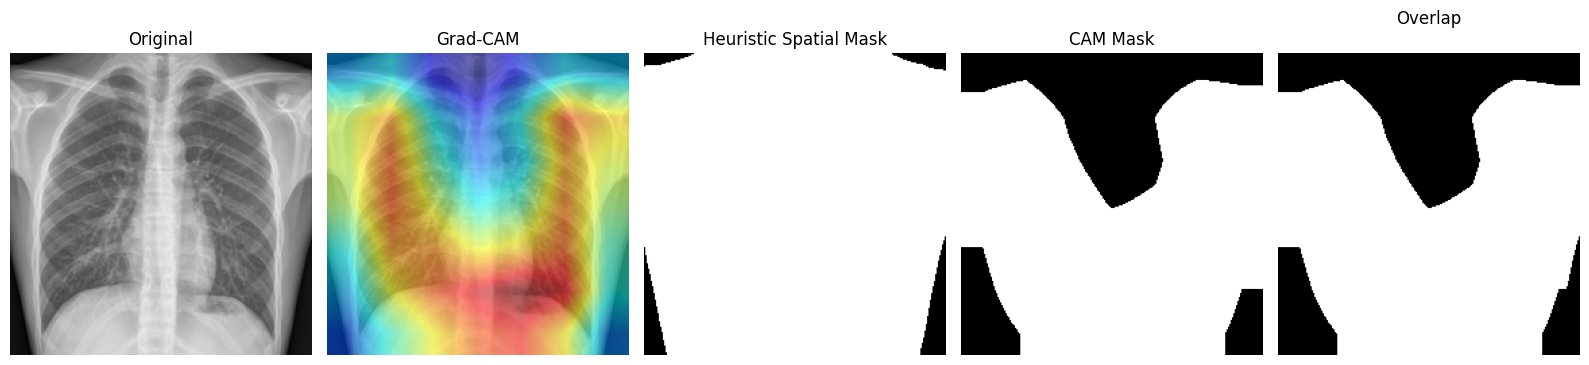

In [ ]:
visualize_validation_result(sample_path, validation_result)

In [ ]:
# ============================================================
# SYSTEMATIC EXPLORATORY GRAD-CAM ANALYSIS
# ============================================================

xai_records = []

for index, (img_path, true_label) in enumerate(
    test_dataset.samples
):

    try:

        result = run_validation_tool(
            image_path=img_path,
            cam_threshold=0.4,
            iou_threshold=0.4
        )

        predicted_label = (
            1
            if result["prediction"]
            == "PNEUMONIA"
            else 0
        )

        xai_records.append({
            "index":
                index,

            "filepath":
                img_path,

            "true_label":
                true_label,

            "predicted_label":
                predicted_label,

            "correct":
                int(
                    predicted_label
                    == true_label
                ),

            "spatial_iou":
                result[
                    "spatial_iou"
                ],

            "pointing_game_hit":
                result[
                    "pointing_game_hit"
                ],

            "perturbation_probability_drop":
                result[
                    "perturbation_probability_drop"
                ],

            "critic_gate":
                result[
                    "critic_gate"
                ]
        })

    except Exception as error:

        xai_records.append({
            "index":
                index,

            "filepath":
                img_path,

            "true_label":
                true_label,

            "predicted_label":
                np.nan,

            "correct":
                np.nan,

            "spatial_iou":
                np.nan,

            "pointing_game_hit":
                np.nan,

            "perturbation_probability_drop":
                np.nan,

            "critic_gate":
                "PROCESSING_ERROR",

            "error":
                str(error)
        })

xai_results_df = pd.DataFrame(
    xai_records
)

display(
    xai_results_df.head()
)

,index,filepath,true_label,predicted_label,correct,spatial_iou,pointing_game_hit,perturbation_probability_drop,critic_gate
0,0,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0,0,1,0.739875,1,0.791826,PASS
1,1,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0,0,1,0.221397,1,0.334485,FLAG
2,2,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0,0,1,0.350520,1,0.604812,FLAG
3,3,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0,0,1,0.625359,1,0.735485,PASS
4,4,/content/chest_xray/chest_xray/test/NORMAL/IM-...,0,0,1,0.353456,1,0.548193,FLAG


In [ ]:
valid_xai_df = (
    xai_results_df
    .dropna(
        subset=[
            "spatial_iou",
            "pointing_game_hit",
            "perturbation_probability_drop"
        ]
    )
)

xai_summary = {
    "evaluated_images":
        len(valid_xai_df),

    "processing_failures":
        (
            len(xai_results_df)
            -
            len(valid_xai_df)
        ),

    "mean_spatial_iou":
        valid_xai_df[
            "spatial_iou"
        ].mean(),

    "median_spatial_iou":
        valid_xai_df[
            "spatial_iou"
        ].median(),

    "pointing_game_hit_rate":
        valid_xai_df[
            "pointing_game_hit"
        ].mean(),

    "mean_probability_drop":
        valid_xai_df[
            "perturbation_probability_drop"
        ].mean(),

    "median_probability_drop":
        valid_xai_df[
            "perturbation_probability_drop"
        ].median(),

    "negative_probability_drop_rate":
        (
            valid_xai_df[
                "perturbation_probability_drop"
            ]
            < 0
        ).mean(),

    "critic_pass_rate":
        (
            valid_xai_df[
                "critic_gate"
            ]
            == "PASS"
        ).mean()
}

xai_summary_df = pd.DataFrame(
    [xai_summary]
)

display(
    xai_summary_df
)

,evaluated_images,processing_failures,mean_spatial_iou,median_spatial_iou,pointing_game_hit_rate,mean_probability_drop,median_probability_drop,negative_probability_drop_rate,critic_pass_rate
0,624,0,0.403301,0.397673,0.939103,0.201869,0.074493,0.008013,0.479167


In [ ]:
xai_results_df.to_csv(
    f"xai_results_{RUN_ID}.csv",
    index=False
)

xai_summary_df.to_csv(
    f"xai_summary_{RUN_ID}.csv",
    index=False
)

print(
    "XAI artifacts saved."
)

XAI artifacts saved.


# Perturbation Threshold Sensitivity

The following exploratory analysis repeats the perturbation experiment using several Grad-CAM thresholds. The probability change is interpreted only as perturbation sensitivity and not as definitive causal faithfulness.

In [ ]:
# ============================================================
# PERTURBATION THRESHOLD SENSITIVITY
# ============================================================

PERTURBATION_THRESHOLDS = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6
]

perturbation_threshold_records = []

for threshold_value in PERTURBATION_THRESHOLDS:

    probability_drops = []

    for img_path, true_label in test_dataset.samples:

        explanation_result = run_explanation_tool(
            image_path=img_path,
            cam_threshold=threshold_value
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        input_tensor = (
            test_transform(image)
            .unsqueeze(0)
            .to(device)
        )

        (
            original_probability,
            masked_probability,
            probability_drop,
            _
        ) = compute_perturbation_sensitivity(
            model=best_resnet18,
            input_tensor=input_tensor,
            grayscale_cam=explanation_result[
                "grayscale_cam"
            ],
            target_class=explanation_result[
                "pred_class_idx"
            ],
            threshold=threshold_value
        )

        probability_drops.append(
            probability_drop
        )

    probability_drops = np.asarray(
        probability_drops
    )

    perturbation_threshold_records.append({
        "threshold":
            threshold_value,

        "mean_probability_drop":
            probability_drops.mean(),

        "median_probability_drop":
            np.median(
                probability_drops
            ),

        "std_probability_drop":
            probability_drops.std(),

        "negative_drop_rate":
            (
                probability_drops < 0
            ).mean()
    })

perturbation_threshold_df = pd.DataFrame(
    perturbation_threshold_records
)

display(
    perturbation_threshold_df
)

,threshold,mean_probability_drop,median_probability_drop,std_probability_drop,negative_drop_rate
0,0.2,0.249764,0.048692,0.318406,0.012821
1,0.3,0.231671,0.081494,0.288330,0.011218
2,0.4,0.201869,0.074493,0.253343,0.008013
3,0.5,0.178076,0.068322,0.222374,0.006410
4,0.6,0.149504,0.048870,0.194116,0.008013


In [ ]:
perturbation_threshold_path = (
    f"perturbation_threshold_sensitivity_{RUN_ID}.csv"
)

perturbation_threshold_df.to_csv(
    perturbation_threshold_path,
    index=False
)

print(
    "Saved:",
    perturbation_threshold_path
)

Saved: perturbation_threshold_sensitivity_20260827_103144.csv


In [ ]:
# ============================================================
# CAM THRESHOLD SENSITIVITY ANALYSIS
# ============================================================

CAM_THRESHOLDS = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6
]

threshold_records = []

for cam_threshold_value in CAM_THRESHOLDS:

    iou_values = []
    pointing_values = []

    for img_path, true_label in test_dataset.samples:

        explanation_result = (
            run_explanation_tool(
                image_path=img_path,
                cam_threshold=
                    cam_threshold_value
            )
        )

        image = Image.open(
            img_path
        ).convert("RGB")

        heuristic_mask = (
            get_heuristic_spatial_mask(
                image
            )
        )

        cam_mask = (
            explanation_result[
                "cam_mask"
            ]
        )

        spatial_iou = compute_iou(
            heuristic_mask,
            cam_mask
        )

        pointing_hit, _ = (
            pointing_game_score(
                explanation_result[
                    "grayscale_cam"
                ],
                heuristic_mask
            )
        )

        iou_values.append(
            spatial_iou
        )

        pointing_values.append(
            pointing_hit
        )

    threshold_records.append({
        "cam_threshold":
            cam_threshold_value,

        "mean_spatial_iou":
            np.mean(
                iou_values
            ),

        "median_spatial_iou":
            np.median(
                iou_values
            ),

        "pointing_game_hit_rate":
            np.mean(
                pointing_values
            )
    })

cam_threshold_sensitivity_df = (
    pd.DataFrame(
        threshold_records
    )
)

display(
    cam_threshold_sensitivity_df
)

,cam_threshold,mean_spatial_iou,median_spatial_iou,pointing_game_hit_rate
0,0.2,0.585277,0.609737,0.939103
1,0.3,0.493520,0.503499,0.939103
2,0.4,0.403301,0.397673,0.939103
3,0.5,0.311784,0.285461,0.939103
4,0.6,0.221894,0.187517,0.939103


In [ ]:
cam_threshold_sensitivity_df.to_csv(
    f"cam_threshold_sensitivity_{RUN_ID}.csv",
    index=False
)

# LLM-Based Multi-Agent Workflow

In [ ]:
# ============================================================
# GEMINI LIVE BACKEND SETUP - Google Gen AI SDK
# Run this BEFORE call_llm_agent()
# ============================================================

!pip install -q -U google-genai

import os
import pandas as pd
from getpass import getpass
from google import genai

# Option 1: Colab secret varsa onu kullan
try:
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
except Exception:
    GEMINI_API_KEY = None

# Option 2: Secret yoksa elle gir
if GEMINI_API_KEY is None or len(str(GEMINI_API_KEY).strip()) == 0:
    GEMINI_API_KEY = getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini client created successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.57.0 which is incompatible.
Gemini client created successfully.


In [ ]:
# ============================================================
# FIND A WORKING GEMINI MODEL
# ============================================================

CANDIDATE_MODELS = [
    "gemini-2.5-flash",
    "gemini-2.0-flash",
    "gemini-1.5-flash",
    "models/gemini-2.5-flash",
    "models/gemini-2.0-flash",
    "models/gemini-1.5-flash",
]

WORKING_GEMINI_MODEL = None
MODEL_TEST_ERRORS = []

for model_name in CANDIDATE_MODELS:
    try:
        test_response = client.models.generate_content(
            model=model_name,
            contents="Reply only with: OK"
        )

        if test_response.text and len(test_response.text.strip()) > 0:
            WORKING_GEMINI_MODEL = model_name
            print(f"Working Gemini model found: {WORKING_GEMINI_MODEL}")
            print("Test response:", test_response.text.strip())
            break

    except Exception as e:
        MODEL_TEST_ERRORS.append((model_name, str(e)))
        print(f"Model failed: {model_name}")
        print(str(e)[:300])
        print("-" * 60)

if WORKING_GEMINI_MODEL is None:
    print("No working Gemini model was found.")
    print("Check your API key, model access, or Google AI Studio API settings.")
else:
    print("Use this model in live agent calls:", WORKING_GEMINI_MODEL)

Working Gemini model found: gemini-2.5-flash
Test response: OK
Use this model in live agent calls: gemini-2.5-flash


In [ ]:
#Ortak LLM çağırma fonksiyonu

# ============================================================
# LLM CALL TRACKER: Live Gemini vs Controlled Fallback Frequency
# ============================================================

AGENT_CALL_LOG = []

def call_llm_agent(agent_name, system_prompt, user_prompt, model_name=None):
    used_backend = "live_gemini"
    error_message = None

    selected_model = model_name if model_name is not None else WORKING_GEMINI_MODEL

    try:
        if selected_model is None:
            raise ValueError("No working Gemini model is available.")

        full_prompt = f"""
You are the {agent_name} in an explainable multi-agent medical imaging workflow.

System instruction:
{system_prompt}

Task / user message:
{user_prompt}

Write a concise, scientific, and non-clinical response.
Do not invent numerical metrics. Only refer to values provided in the prompt.
"""

        response = client.models.generate_content(
            model=selected_model,
            contents=full_prompt
        )

        text_response = response.text

        if text_response is None or len(text_response.strip()) == 0:
            raise ValueError("Gemini returned an empty response.")

    except Exception as e:
        used_backend = "controlled_fallback"
        error_message = str(e)

        text_response = f"""
[{agent_name} controlled fallback response]
The live Gemini backend was unavailable during this call.
The workflow continues using implemented tool outputs.
This fallback text is used only for agent-language reporting and does not modify
model predictions, Grad-CAM maps, IoU, Pointing Game, faithfulness,
confusion matrices, ROC-AUC, F1-score, or any other quantitative metric.
"""

    AGENT_CALL_LOG.append({
        "agent_name": agent_name,
        "backend": used_backend,
        "model": selected_model,
        "error": error_message
    })

    print(f"\n===== {agent_name} RESPONSE | backend: {used_backend} =====")
    print(text_response)
    print("=" * 70)

    return text_response


def summarize_agent_backend_usage():
    log_df = pd.DataFrame(AGENT_CALL_LOG)

    if len(log_df) == 0:
        print("No LLM agent calls were recorded.")
        return None, None

    summary = (
        log_df["backend"]
        .value_counts()
        .rename_axis("Backend")
        .reset_index(name="Number of calls")
    )

    summary["Percentage"] = 100 * summary["Number of calls"] / summary["Number of calls"].sum()

    display(summary)
    display(log_df)

    summary.to_csv("llm_backend_usage_summary.csv", index=False)
    log_df.to_csv("llm_backend_call_log.csv", index=False)

    return summary, log_df

Agent promptlarını tanımla:

In [ ]:
coordinator_prompt = """
You are the Coordinator Agent in a research software
orchestration demonstration for chest X-ray analysis.

Your role is to coordinate deterministic tools and agents.

The Vision Tool performs classification.
The Explanation Tool generates Grad-CAM.
The deterministic Critic gate evaluates predefined
exploratory checks.

Do not claim clinical diagnosis, clinical reliability,
or explanation correctness.

The LLM agents do not alter model predictions,
Grad-CAM outputs, or quantitative metrics.
"""

vision_agent_prompt = """
You are the Vision Agent.

You receive the output of a trained ResNet-18
classification tool.

Report the predicted class and model-predicted
probability exactly as supplied by the tool.

Do not modify numerical values.
Do not provide a clinical diagnosis.
Do not make treatment recommendations.

Forward the tool output to the Explanation Agent.
"""

explanation_agent_prompt = """
You are the Explanation Agent.

You receive a deterministic Grad-CAM explanation
generated by the implemented computer-vision tool.

Your role is only to communicate that a Grad-CAM
map was generated and forward the tool result
to the Critic Agent.

Do not claim that the explanation is clinically correct,
reliable, anatomically validated, or medically meaningful.

SHAP is not part of this agent pipeline.
"""

critic_agent_prompt = """
You are the Critic Agent.

You receive deterministic exploratory metrics:
- spatial IoU against a heuristic spatial reference mask,
- Pointing Game hit,
- perturbation probability drop,
- the predefined deterministic PASS/FLAG gate.

You must explain the supplied tool outputs without
changing them.

The heuristic reference mask is not anatomical
ground truth and the gate is not a clinical validation
criterion.

Do not override the deterministic PASS/FLAG result.
Do not request CAM-threshold refinement.
Do not claim explanation correctness or clinical reliability.
"""

report_agent_prompt = """
You are the Report Agent.

Prepare a concise research-demonstration summary
using only the deterministic tool outputs and the
conversation history.

Report:
- predicted class,
- model-predicted probability,
- exploratory spatial IoU,
- Pointing Game result,
- perturbation probability drop,
- deterministic PASS/FLAG result.

State explicitly that:
- the heuristic spatial mask is not anatomical ground truth,
- the output is not a clinical diagnosis,
- the LLM layer only summarizes deterministic tool outputs.

Do not introduce unsupported clinical claims.
"""

## LLM Backend Execution Log

In [ ]:
# Summarize live Gemini vs fallback usage after running the agent workflow
backend_summary, backend_log = summarize_agent_backend_usage()

No LLM agent calls were recorded.


# Autonomous Multi-Agent Reasoning Loop

In [ ]:
# ============================================================
# REAL CONVERSATIONAL MULTI-AGENT HELPERS
# ============================================================
# Improved Conversational Multi-Agent Reasoning Loop

def add_message(state, sender, receiver, message):
    """
    Ortak konuşma geçmişine yeni agent mesajı ekler.
    Bu sayede agentlar birbirlerinin önceki mesajlarını görebilir.
    """
    state["messages"].append({
        "sender": sender,
        "receiver": receiver,
        "message": message
    })


def format_conversation_history(state):
    """
    Tüm agent konuşmalarını LLM prompt'una koymak için metne çevirir.
    """
    if len(state["messages"]) == 0:
        return "No previous messages."

    conversation_text = ""

    for msg in state["messages"]:
        conversation_text += f"\n[{msg['sender']} → {msg['receiver']}]\n{msg['message']}\n"

    return conversation_text


def print_conversation_history(state):
    """
    Konuşmayı okunabilir şekilde yazdırır.
    """
    print("\n" + "=" * 70)
    print("MULTI-AGENT CONVERSATION HISTORY")
    print("=" * 70)

    for msg in state["messages"]:
        print(f"\n[{msg['sender']} → {msg['receiver']}]")
        print(msg["message"])

    print("=" * 70)

In [ ]:
# ============================================================
# FINAL CONVERSATIONAL MULTI-AGENT ORCHESTRATION
# NO THRESHOLD RETRY / NO TEST-TIME REFINEMENT
# ============================================================

def run_conversational_multi_agent_loop(
    image_path,
    true_label=None,
    cam_threshold=0.4,
    iou_threshold=0.4
):
    """
    Multi-agent software orchestration demonstration.

    Scientific calculations are performed by
    deterministic computer-vision tools.

    The LLM agents only communicate and summarize
    the tool outputs.

    No CAM threshold is changed after observing
    the test result.
    """

    state = {
        "image_path":
            image_path,

        "true_label":
            true_label,

        "messages":
            [],

        "vision_result":
            None,

        "explanation_result":
            None,

        "validation_result":
            None,

        "final_decision":
            None
    }

    # --------------------------------------------------------
    # Coordinator Agent
    # --------------------------------------------------------

    coordinator_response = call_llm_agent(
        agent_name=
            "Coordinator Agent",

        system_prompt=
            coordinator_prompt,

        user_prompt=f"""
A chest X-ray image has been provided.

Please instruct the Vision Agent to run the
pretrained classification tool.

Do not provide a clinical diagnosis.

Conversation history:
{format_conversation_history(state)}
"""
    )

    add_message(
        state,
        "Coordinator Agent",
        "Vision Agent",
        coordinator_response
    )

    # --------------------------------------------------------
    # Vision Tool
    # --------------------------------------------------------

    vision_result = run_vision_tool(
        image_path
    )

    state["vision_result"] = (
        vision_result
    )

    vision_response = call_llm_agent(
        agent_name=
            "Vision Agent",

        system_prompt=
            vision_agent_prompt,

        user_prompt=f"""
Vision Tool output:

Prediction:
{vision_result['prediction']}

Model predicted probability:
{vision_result['confidence']:.4f}

Please communicate this tool output to the
Explanation Agent and request a Grad-CAM map.

Do not provide a clinical diagnosis.
"""
    )

    add_message(
        state,
        "Vision Agent",
        "Explanation Agent",
        vision_response
    )

    # --------------------------------------------------------
    # Explanation Tool
    # --------------------------------------------------------

    explanation_result = (
        run_explanation_tool(
            image_path=image_path,
            cam_threshold=
                cam_threshold
        )
    )

    state[
        "explanation_result"
    ] = explanation_result

    explanation_response = (
        call_llm_agent(
            agent_name=
                "Explanation Agent",

            system_prompt=
                explanation_agent_prompt,

            user_prompt=f"""
A Grad-CAM explanation was generated.

Prediction explained:
{explanation_result['prediction']}

CAM threshold:
{cam_threshold}

Please send the tool result to the Critic Agent
for deterministic exploratory evaluation.

Do not claim clinical explanation correctness.
"""
        )
    )

    add_message(
        state,
        "Explanation Agent",
        "Critic Agent",
        explanation_response
    )

    # --------------------------------------------------------
    # Deterministic Validation Tool
    # --------------------------------------------------------

    validation_result = (
        run_validation_tool(
            image_path=
                image_path,

            cam_threshold=
                cam_threshold,

            iou_threshold=
                iou_threshold
        )
    )

    state[
        "validation_result"
    ] = validation_result

    state[
        "final_decision"
    ] = validation_result[
        "critic_gate"
    ]

    # --------------------------------------------------------
    # Critic Agent
    # LLM DOES NOT determine numeric routing.
    # --------------------------------------------------------

    critic_response = (
        call_llm_agent(
            agent_name=
                "Critic Agent",

            system_prompt=
                critic_agent_prompt,

            user_prompt=f"""
The deterministic validation tool produced:

Exploratory spatial IoU:
{validation_result['spatial_iou']:.4f}

Pointing Game hit:
{validation_result['pointing_game_hit']}

Perturbation probability drop:
{validation_result['perturbation_probability_drop']:.4f}

Predefined deterministic gate:
{validation_result['critic_gate']}

Checks:
{validation_result['critic_checks']}

Explain these results briefly.

Do not override the deterministic gate.
Do not claim clinical explanation correctness.
"""
        )
    )

    add_message(
        state,
        "Critic Agent",
        "Report Agent",
        critic_response
    )

    # --------------------------------------------------------
    # Report Agent
    # --------------------------------------------------------

    report_response = (
        call_llm_agent(
            agent_name=
                "Report Agent",

            system_prompt=
                report_agent_prompt,

            user_prompt=f"""
Prepare a research-demonstration summary.

Prediction:
{vision_result['prediction']}

Model predicted probability:
{vision_result['confidence']:.4f}

Exploratory spatial IoU:
{validation_result['spatial_iou']:.4f}

Pointing Game:
{validation_result['pointing_game_hit']}

Perturbation probability drop:
{validation_result['perturbation_probability_drop']:.4f}

Deterministic gate:
{validation_result['critic_gate']}

State clearly that:
- the heuristic mask is not anatomical ground truth,
- the result is not a clinical diagnosis,
- the LLM only summarizes deterministic tool outputs.
"""
        )
    )

    state[
        "report_response"
    ] = report_response

    add_message(
        state,
        "Report Agent",
        "User / Researcher",
        report_response
    )

    return state

In [ ]:
# ============================================================
# OPTIONAL SINGLE-SAMPLE MULTI-AGENT DEMO
# ============================================================

sample_path, sample_label = (
    random.choice(
        test_dataset.samples
    )
)

true_label_name = (
    test_dataset.classes[
        sample_label
    ]
)

conversational_result = (
    run_conversational_multi_agent_loop(
        image_path=
            sample_path,

        true_label=
            true_label_name,

        cam_threshold=
            0.4,

        iou_threshold=
            0.4
    )
)

print_conversation_history(
    conversational_result
)


===== Coordinator Agent RESPONSE | backend: live_gemini =====
Instructing Vision Agent: Execute pretrained classification tool on the provided chest X-ray image.

===== Vision Agent RESPONSE | backend: live_gemini =====
Forwarding the ResNet-18 classification tool output to the Explanation Agent.

**Vision Tool Output:**
Predicted class: NORMAL
Model-predicted probability: 0.9774

Requesting a Grad-CAM localization map for interpretability.

===== Explanation Agent RESPONSE | backend: live_gemini =====
A Grad-CAM explanation was generated for the prediction "NORMAL" with a CAM threshold of 0.4. This tool output is being forwarded to the Critic Agent for deterministic exploratory evaluation.

===== Critic Agent RESPONSE | backend: live_gemini =====
The predefined deterministic gate yielded a PASS result.

Exploratory spatial IoU, measured against a heuristic spatial reference mask, was 0.4249, indicating moderate overlap. A Pointing Game hit of 1 confirms that the most salient point lo

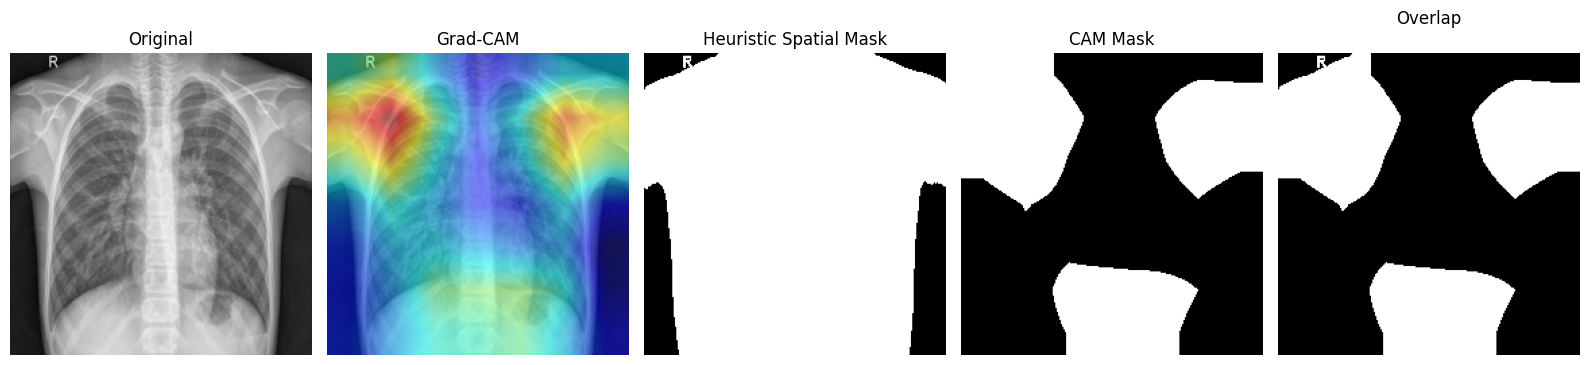

In [ ]:
# ============================================================
# VISUALIZE FINAL VALIDATION RESULT
# ============================================================

visualize_validation_result(
    sample_path,
    conversational_result["validation_result"]
)